# Profile-based QUT simulation experiments

This notebook is the reusable profile-simulation workflow derived from `Simulation_construction.ipynb`. It tests the QUT method over the complete Cartesian product of:

- exhaustive bootstrap prefixes: 50 and 100;
- possessions per bootstrap: 1,000 and 2,500; and
- samples per possession: 150, 200, and 250.

Every synthetic game contains four quarters. The same simulated outcomes are analyzed as one pooled **full-game** sample and as **quarter 1-4** samples. Complete real possession trajectories are sampled first and passed through `bin_and_flip(..., flip="no")`; in the current helper implementation, `"no"` activates the rotations that orient play from left to right.

Bootstrap counts use a paired nested-prefix design. For each profile/scope/possession/sample setting, deterministic bootstrap slots are generated once up to `max(BOOTSTRAP_VALUES)`. Every smaller B uses a prefix of that same stream. QUT confidence intervals and prefix-median coefficient maps are therefore directly comparable across bootstrap counts.

## How to run the notebook

### Before starting

1. Start the notebook with the repository root as the working directory. `full_game_data.csv`, `nba_court_T.png`, `funcs.py`, and the `multi_game_data/` source directory must be available at the paths configured in Section 0.
2. Use the Python environment that contains NumPy, pandas, SciPy, Matplotlib, scikit-learn, CVXPY, and the notebook dependencies imported in Section 0.
3. Restart the kernel before changing an experiment axis. Run cells in order; do not execute Section 4 against stale variables from an older plan.
4. Leave `RESUME_FROM_CHECKPOINT = True`. A completed semantic `run_id` is skipped only after its simulation tag, sweep series, seed policy, profile, scope, B/P/S values, and seeds all match the current plan.

### Normal fresh or resumed run

1. Run Sections 0-2. These cells load the source data, orient every possession left-to-right, build the shared eight-game trajectory sample, plant each profile, and create the full-game and quarter inputs.
2. Section 3 is optional and independent of the exhaustive axes. Set `RUN_INDIVIDUAL_PROFILE_EXPERIMENTS = False` when only the exhaustive sweep is needed. When it is `True`, its own checkpoint safely skips completed profile-like runs.
3. Run the first cell in Section 4 and inspect `build_unique_configurations()` plus the grouped coverage table. With the current axes it must contain 12 B/P/S configurations, 6 P/S cells for each B, 120 underlying streams, and 240 summary rows.
4. In the execution cell, keep `RUN_PARAMETER_SWEEP = True`, `RESUME_FROM_CHECKPOINT = True`, `SELECTED_PROFILES = PROFILES_TO_SIMULATE`, `SELECTED_SCOPES = ANALYSIS_SCOPES`, and `SELECTED_RUN_IDS = None` for an exhaustive run. Normally set `STREAM_SETTINGS_PER_PROFILE_PER_BATCH = None`; `None` runs every unfinished P/S stream. An integer such as `1` limits one P/S setting per profile per execution; rerun the cell until it reports every row complete.
5. Section 4A is the selected eight-game validation. It runs B=500/P=1,000/S=100 plus the five settings frozen from the prior ten-game overall ranking, for every profile and scope. Keep `RUN_SELECTED_VALIDATION = True` to run or resume it. This is deliberately a six-setting plan, not a Cartesian sweep; each shared P/S stream is computed only through the largest selected B it needs.
6. Run Section 5 to rewrite and display inline the 16 factorial QUT overview figures for the active Cartesian plan. In Section 6, keep `RUN_PROFILE_MAP_COMPARISON = True`, `PLOT_FACTORIAL_SIMILARITY = True`, and `PLOT_DETAILED_RECOVERED_MAPS = True`; leave `OVERWRITE_EXISTING_DETAILED_PLOTS = False` unless every detailed image must be deliberately regenerated. Section 6 reads the cumulative checkpoints, recalculates support-aware metrics for **all completed seeded configurations**, rewrites and displays the 12 all-history similarity overviews, and creates any missing detailed figures. Detailed maps are saved externally but are not displayed inline unless `DISPLAY_DETAILED_RECOVERED_MAPS_INLINE = True`, because embedding all of them makes the notebook very large. Finally, run Section 7 to write and display the best-to-worst overall table and the per-profile ranking table.

The main outputs are stored under `profile_sim_results/` using `SWEEP_TAG`: cumulative per-profile checkpoints under `sweeps/`; resumable stream caches under `nested_streams/` or `selected_nested_streams/`; all-completed similarity metrics under `nested_maps/`; and profile figures under `heatmaps/`. Excel-friendly ranking copies are written to `profile_sim_results/tables/<N>_games/`. A failed or interrupted stream can be resumed by rerunning its execution cell.

Per-profile checkpoint CSVs are cumulative within a sweep series, while `load_sweep_summary()` returns only rows belonging to the active Cartesian plan. Seeing more rows in a per-profile CSV than in the current plan is therefore normal. If an exception occurs after the console prints the final `Checkpoint saved` message, restart the kernel and rerun Sections 0-2 and 4: validated streams will report as complete and will not be refitted.

### Example: add one bootstrap amount without rerunning completed work

Suppose B=75 should be added to the exhaustive grid. Change only the sorted tuple in Section 4 to `BOOTSTRAP_VALUES = (50, 75, 100)`. **Do not change `SWEEP_SERIES_ID`** for this compatible axis extension. Restart the kernel and run Sections 0-2 and 4 in order with resume enabled.

The plan will grow from 240 to 360 rows: one new B value x 2 possession values x 3 sample values x 4 profiles x 5 scopes = 120 new exhaustive cases. The existing B=50/100 rows retain their semantic IDs and seeds. Because every cached stream already contains 100 slots, B=75 is derived from the first 75 cached lambda values and maps; no bootstrap dataset or TV-logistic map is refitted. The console should validate each cache at `100/100` and add only the missing B=75 summary rows.

Then run Sections 5-7. The active-plan QUT overviews and all-completed similarity overviews are intentionally rewritten because they need a new B row. With `OVERWRITE_EXISTING_DETAILED_PLOTS = False`, every existing completed-run detailed figure is retained and only the 24 new B=75 figures are created. The rankings are rebuilt from the cumulative successful history and will include B=10, 50, 75, and 100 configurations.

If a new exhaustive amount is larger than the cached maximum, for example `BOOTSTRAP_VALUES = (50, 100, 200)`, the same workflow expands each of the 120 current-plan caches and computes only slots 101-200. The first 100 slots, their seeds, and all existing prefix results are reused. This example requires 12,000 new slot fits, so use batching and expect a long run. B=500 remains prohibited in the exhaustive plan and is used only by an explicitly selected validation such as Section 4A.

Checkpoint CSVs intentionally retain successful rows from earlier grids in the same sweep series. Section 4 and the QUT overviews filter that history to the active semantic `run_id` values, whereas Sections 6-7 deliberately use all compatible completed history for maps and rankings. Removing a reporting prefix or changing the displayed P/S subset therefore does not invalidate compatible slot caches or erase older comparisons. Do not reduce `max(BOOTSTRAP_VALUES)` inside the same series. If the seed policy, estimator, model, or interpretation changes, assign a new `SWEEP_SERIES_ID` so incompatible caches cannot be reused. Changes already represented in `SIMULATION_TAG`—source games, planted profiles, baseline probability, grid, MC null settings, alpha, and source-sample threshold—automatically create a separate output namespace.

Every expensive stream is independently cached and resumable. Generated caches and figures remain outside the tracked source set.


## 0. Imports and shared settings

The notebook imports the QUT primitives needed for resumable nested-prefix execution. Simulation, checkpoint, comparison, and plotting helpers remain here so the experiment design is explicit and auditable.


In [1]:
from itertools import product
from pathlib import Path
from time import perf_counter, sleep
import gc
import hashlib
import shutil
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image as IPythonImage, display

from funcs import (
    analyze_tv_logistic_single_game,
    bin_and_flip,
    grid,
    iter_bootstrapped_datasets,
    lambda_qut,
    solve_infinity_norm,
    tv_logistic_regression_heatmap,
)

warnings.filterwarnings("ignore")

DATA_PATH = Path("multi_game_data/multi_game_data_half_court_filtered.csv")
COURT_IMAGE_PATH = "court.jpg"

X_BINS = 20
Y_BINS = 10
POSSESSION_KEYS = ["game_id", "possession_number"]

SIMULATION_TRAIN_GAMES = (
    21500649,
    21500390,
    21500188,
    21500355,
    21500057,
    21500009,
    21500540,
    21500131,
    21500272,
    21500196,
)

# Eight games require 736 trajectory draws from the 758-possession source pool.
# Sampling therefore uses replacement; Section 2 reports the realized reuse rate.
N_SIMULATED_GAMES = 8
POSSESSIONS_PER_GAME = 92
QUARTERS_PER_GAME = 4
POSSESSIONS_PER_QUARTER = POSSESSIONS_PER_GAME // QUARTERS_PER_GAME

TRAJECTORY_SEED = 142
OUTCOME_SEED = 242
BASELINE_SCORING_PROBABILITY = 0.1
ALPHA = 0.05
MC_NULL = 100
MIN_SOURCE_SAMPLES = 100

SOURCE_GAME_FINGERPRINT = hashlib.sha256(
    ",".join(map(str, SIMULATION_TRAIN_GAMES)).encode("utf-8")
).hexdigest()[:10]
SIMULATION_BASE_TAG = (
    f"games{N_SIMULATED_GAMES}_possessions{POSSESSIONS_PER_GAME}_"
    f"source{SOURCE_GAME_FINGERPRINT}_grid{X_BINS}x{Y_BINS}_"
    f"trajectory{TRAJECTORY_SEED}_outcome{OUTCOME_SEED}_"
    f"baseline{BASELINE_SCORING_PROBABILITY:.2f}_"
    f"mc{MC_NULL}_alpha{ALPHA:.2f}_min{MIN_SOURCE_SAMPLES}"
)
# Finalized after SIMULATION_PROFILES is defined.
SIMULATION_TAG = SIMULATION_BASE_TAG
RESULTS_ROOT = Path("profile_sim_results")


def fixed_simulation_label():
    return (
        f"source games={len(SIMULATION_TRAIN_GAMES):,} | "
        f"simulated games={N_SIMULATED_GAMES:,} | "
        f"possessions/game={POSSESSIONS_PER_GAME:,} | "
        f"quarters/game={QUARTERS_PER_GAME:,}\n"
        f"baseline scoring probability={BASELINE_SCORING_PROBABILITY:g} | "
        f"grid={X_BINS}x{Y_BINS} | orientation=left-to-right\n"
        f"alpha={ALPHA:g} | MC null={MC_NULL:,} | "
        f"min source samples={MIN_SOURCE_SAMPLES:,} | "
        f"trajectory seed={TRAJECTORY_SEED} | outcome seed={OUTCOME_SEED} | "
        f"profile fingerprint={PROFILE_DEFINITION_FINGERPRINT}"
    )


if POSSESSIONS_PER_GAME % QUARTERS_PER_GAME:
    raise ValueError("POSSESSIONS_PER_GAME must be divisible by QUARTERS_PER_GAME.")
if not DATA_PATH.exists():
    raise FileNotFoundError(DATA_PATH)
if not Path(COURT_IMAGE_PATH).exists():
    raise FileNotFoundError(COURT_IMAGE_PATH)


## 1. Define the planted profiles

These are the same four spatial profiles used by the individual experiments. The reference profile is also used by the profile-like sanity check below.

In [2]:
reference_movement_effects = np.zeros((X_BINS, Y_BINS))
reference_end_effects = np.zeros((X_BINS, Y_BINS))
reference_movement_effects[10:18, 0:3] = 0.05
reference_movement_effects[18:20, 0:3] = 0.05
reference_movement_effects[18:20, 6] = 0.05
reference_movement_effects[10:20, 6:10] = 0.05
reference_movement_effects[18:20, 2:6] = 0.05
reference_movement_effects[10:18, 2:6] = 0
reference_movement_effects[10:12, 6:8] = 0
reference_movement_effects[10:13, :] = 0
reference_movement_effects[18:20, 2:4] = 0.05

high_y_side_movement_effects = np.zeros((X_BINS, Y_BINS))
high_y_side_end_effects = np.zeros((X_BINS, Y_BINS))
high_y_side_movement_effects[13:20, 5:10] = 0.05

low_y_side_movement_effects = np.zeros((X_BINS, Y_BINS))
low_y_side_end_effects = np.zeros((X_BINS, Y_BINS))
low_y_side_movement_effects[13:20, 0:5] = 0.05

perimeter_movement_effects = np.zeros((X_BINS, Y_BINS))
perimeter_end_effects = np.zeros((X_BINS, Y_BINS))
perimeter_movement_effects[15:20, 9] = 0.05
perimeter_movement_effects[14:18, 8:10] = 0.05
perimeter_movement_effects[14:16, 7:9] = 0.05
perimeter_movement_effects[13:15, 3:7] = 0.05
perimeter_movement_effects[14:20, 0] = 0.05
perimeter_movement_effects[14:18, 1] = 0.05
perimeter_movement_effects[14:16, 2] = 0.05
perimeter_movement_effects[13, 0:10] = 0.05
perimeter_movement_effects[15:20, 3:7] = -0.01
perimeter_movement_effects[18:20, 3:7] = -0.01
perimeter_movement_effects[16:18, 3:7] = -0.01
perimeter_movement_effects[15, 3:7] = 0

SIMULATION_PROFILES = {
    "reference": {
        "label": "Reference court pattern",
        "movement_effects": reference_movement_effects,
        "end_effects": reference_end_effects,
        "seed": 42,
    },
    "high_y_side": {
        "label": "High-y-side emphasis",
        "movement_effects": high_y_side_movement_effects,
        "end_effects": high_y_side_end_effects,
        "seed": 43,
    },
    "low_y_side": {
        "label": "Low-y-side emphasis",
        "movement_effects": low_y_side_movement_effects,
        "end_effects": low_y_side_end_effects,
        "seed": 44,
    },
    "perimeter": {
        "label": "Stepped perimeter pattern",
        "movement_effects": perimeter_movement_effects,
        "end_effects": perimeter_end_effects,
        "seed": 45,
    },
}

# Include every planted surface in the cache/checkpoint identity.
_profile_definition_hasher = hashlib.sha256()
for _profile_name in sorted(SIMULATION_PROFILES):
    _profile_definition_hasher.update(_profile_name.encode("utf-8"))
    for _effect_name in ("movement_effects", "end_effects"):
        _effect_values = np.ascontiguousarray(
            SIMULATION_PROFILES[_profile_name][_effect_name], dtype="<f8"
        )
        _profile_definition_hasher.update(_effect_name.encode("utf-8"))
        _profile_definition_hasher.update(
            np.asarray(_effect_values.shape, dtype="<i8").tobytes()
        )
        _profile_definition_hasher.update(_effect_values.tobytes())
PROFILE_DEFINITION_FINGERPRINT = _profile_definition_hasher.hexdigest()[:10]
SIMULATION_TAG = (
    f"{SIMULATION_BASE_TAG}_profiles{PROFILE_DEFINITION_FINGERPRINT}"
)

pd.DataFrame(
    [
        {"profile": name, "label": profile["label"], "seed": profile["seed"]}
        for name, profile in SIMULATION_PROFILES.items()
    ]
)

,profile,label,seed
0,reference,Reference court pattern,42
1,high_y_side,High-y-side emphasis,43
2,low_y_side,Low-y-side emphasis,44
3,perimeter,Stepped perimeter pattern,45


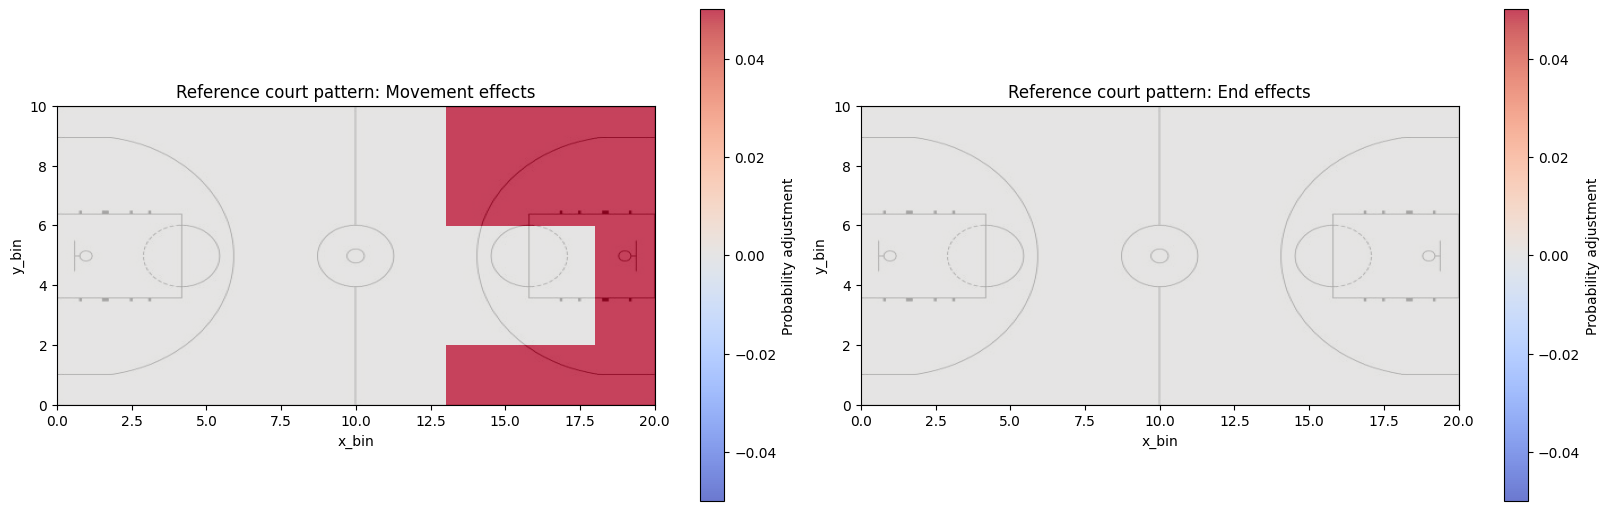

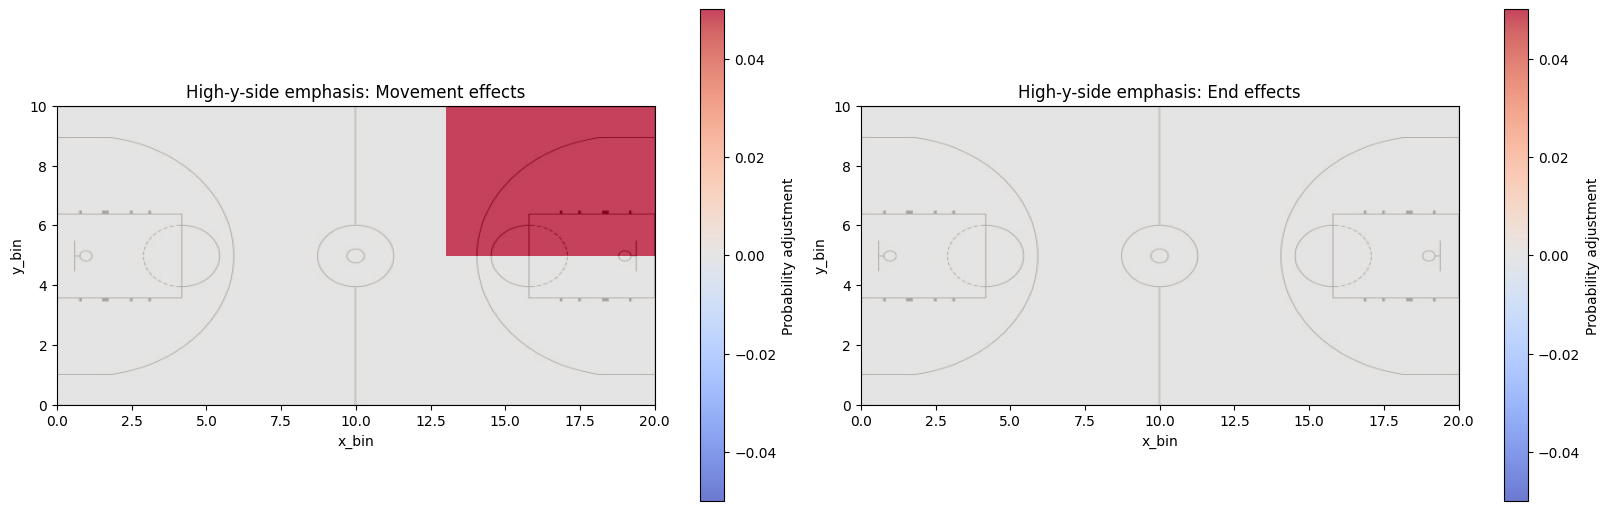

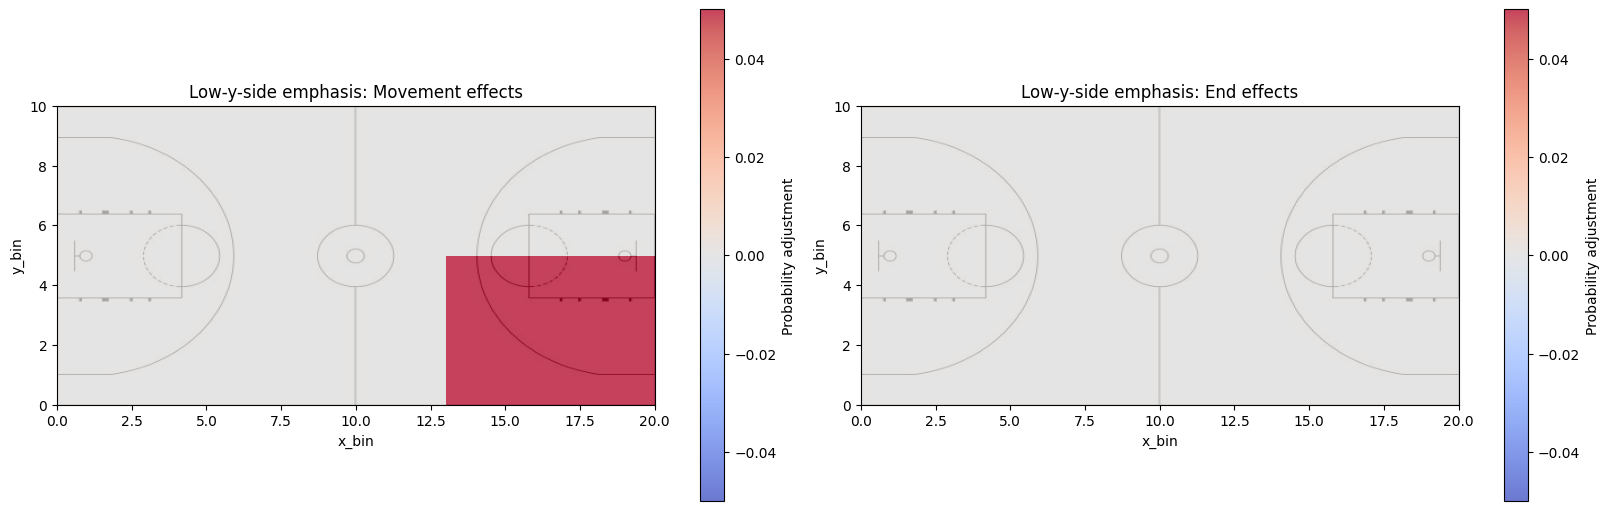

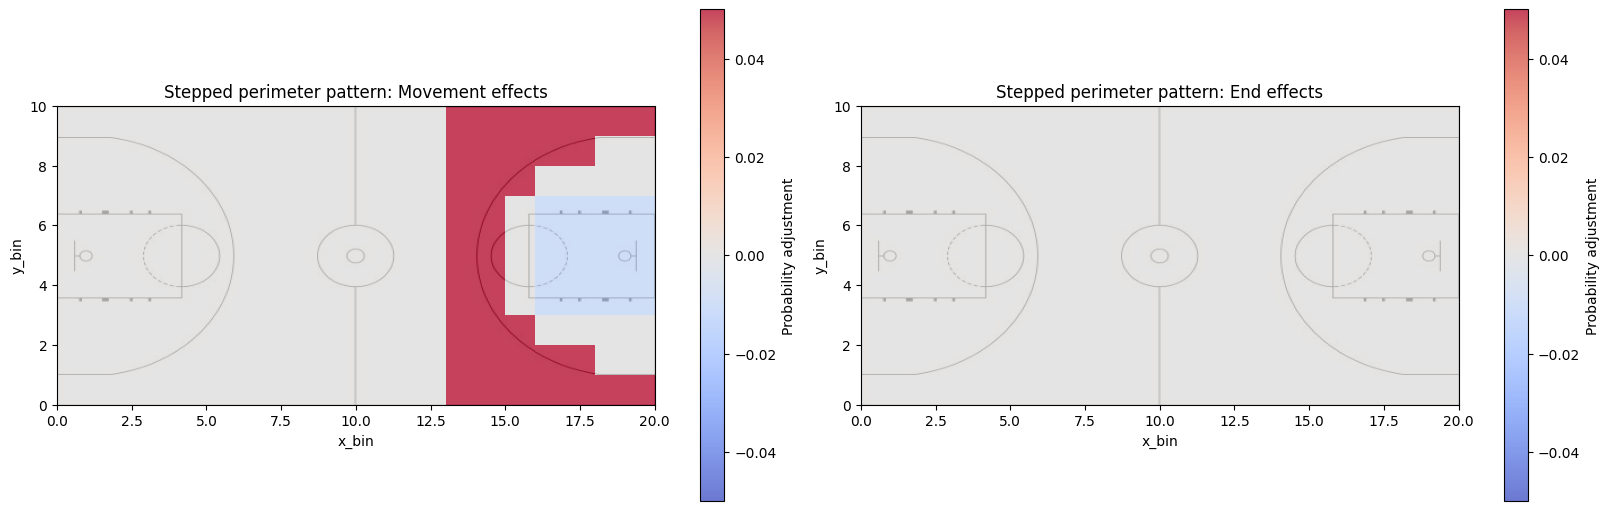

In [3]:
def plot_planted_profile(profile_name, court_image_path=COURT_IMAGE_PATH):
    """Plot a planted movement/end-effect pair using the individual-profile layout."""
    profile = SIMULATION_PROFILES[profile_name]
    effect_maps = [profile["movement_effects"], profile["end_effects"]]
    titles = ["Movement effects", "End effects"]
    scale = max(float(np.abs(effect).max()) for effect in effect_maps) or 1.0
    court = plt.imread(court_image_path)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
    for ax, effect, title in zip(axes, effect_maps, titles):
        ax.imshow(court, extent=[0, X_BINS, 0, Y_BINS], aspect="auto")
        image = ax.imshow(
            effect.T,
            origin="lower",
            extent=[0, X_BINS, 0, Y_BINS],
            cmap="coolwarm",
            alpha=0.75,
            vmin=-scale,
            vmax=scale,
        )
        ax.set(title=f"{profile['label']}: {title}", xlabel="x_bin", ylabel="y_bin")
        fig.colorbar(image, ax=ax, label="Probability adjustment")
    plt.show()


for profile_name in SIMULATION_PROFILES:
    plot_planted_profile(profile_name)

## 2. Build reusable full-game and quarter inputs

The trajectory sample is created once and reused by every planted profile. This keeps changes in the QUT results attributable to the profile or QUT settings rather than a different trajectory sample.

The current design uses all ten games available in the source file and simulates ten 92-possession games. That requests 920 draws from 758 available trajectories, so sampling uses replacement. The validation table reports both the eligible-possession count and realized source-reuse rate for every scope.

`prepare_shared_trajectories` deliberately calls `bin_and_flip(..., flip="no")`. It then verifies that every source game's mean x-bin is on the right half of the oriented grid. Synthetic game and quarter labels are assigned only after this orientation step.

In [4]:
def sample_complete_possessions(
    df,
    game_ids,
    n_possessions,
    seed,
):
    """Sample complete trajectories and give every draw a unique possession ID."""
    source = df[df["game_id"].isin(game_ids)].copy()
    keys = source[POSSESSION_KEYS].drop_duplicates()
    if keys.empty:
        raise ValueError("No source possessions were found for the selected games.")

    draws = keys.sample(
        n=n_possessions,
        replace=n_possessions > len(keys),
        random_state=seed,
    ).reset_index(drop=True)
    draws["_draw_id"] = np.arange(n_possessions, dtype=int)

    sampled = draws.merge(source, on=POSSESSION_KEYS, how="left", validate="many_to_many")
    sampled["source_possession_number_for_sim"] = sampled["possession_number"]
    sampled["possession_number"] = sampled["_draw_id"]
    return sampled.drop(columns="_draw_id")


def prepare_shared_trajectories(
    source,
    game_ids=SIMULATION_TRAIN_GAMES,
    n_games=N_SIMULATED_GAMES,
    possessions_per_game=POSSESSIONS_PER_GAME,
    seed=TRAJECTORY_SEED,
):
    """Sample, orient, bin, and label synthetic games and quarters once."""
    total_possessions = int(n_games * possessions_per_game)
    sampled = sample_complete_possessions(source, game_ids, total_possessions, seed)

    # In funcs.bin_and_flip, flip="no" activates the left-to-right rotations.
    binned = bin_and_flip(
        sampled,
        flip="no",
        x_bins=X_BINS,
        y_bins=Y_BINS,
    )
    binned["sector"] = list(zip(binned["x_bin"], binned["y_bin"]))
    binned["simulation_game"] = binned["possession_number"] // possessions_per_game + 1
    binned["possession_in_game"] = binned["possession_number"] % possessions_per_game
    binned["quarter"] = binned["possession_in_game"] // POSSESSIONS_PER_QUARTER + 1

    source_game_orientation = (
        binned.groupby("game_id", observed=False)["x_bin"]
        .agg(mean_x_bin="mean", n_rows="size")
        .reset_index()
    )
    grid_midpoint = (X_BINS - 1) / 2
    wrong_way_games = source_game_orientation[
        source_game_orientation["mean_x_bin"] < grid_midpoint
    ]
    if not wrong_way_games.empty:
        raise RuntimeError(
            "Left-to-right orientation check failed for source games: "
            f"{wrong_way_games['game_id'].tolist()}"
        )

    game_counts = binned.groupby("simulation_game")["possession_number"].nunique()
    quarter_counts = binned.groupby(["simulation_game", "quarter"])[
        "possession_number"
    ].nunique()
    if not game_counts.eq(possessions_per_game).all():
        raise RuntimeError("Synthetic games do not contain the requested possession count.")
    if not quarter_counts.eq(POSSESSIONS_PER_QUARTER).all():
        raise RuntimeError("Synthetic quarters do not contain the requested possession count.")

    return binned, source_game_orientation


def apply_profile_to_trajectories(
    binned,
    profile_name,
    baseline_probability=BASELINE_SCORING_PROBABILITY,
    outcome_seed=OUTCOME_SEED,
):
    """Plant one profile, draw outcomes, and return QUT inputs by scope."""
    profile = SIMULATION_PROFILES[profile_name]
    movement_effects = profile["movement_effects"]
    end_effects = profile["end_effects"]

    unique_visits = binned.drop_duplicates(POSSESSION_KEYS + ["sector"]).copy()
    unique_visits["movement_adjustment"] = [
        movement_effects[int(x_bin), int(y_bin)]
        for x_bin, y_bin in unique_visits["sector"]
    ]
    movement_adjustments = (
        unique_visits.groupby(POSSESSION_KEYS, observed=False)["movement_adjustment"]
        .sum()
        .reset_index()
    )

    end_sectors = binned.drop_duplicates(POSSESSION_KEYS, keep="last")[
        POSSESSION_KEYS + ["sector"]
    ].copy()
    end_sectors["end_adjustment"] = [
        end_effects[int(x_bin), int(y_bin)] for x_bin, y_bin in end_sectors["sector"]
    ]

    probabilities = movement_adjustments.merge(
        end_sectors[POSSESSION_KEYS + ["end_adjustment"]],
        on=POSSESSION_KEYS,
        how="left",
        validate="one_to_one",
    )
    probabilities["baseline_probability"] = baseline_probability
    probabilities["scoring_probability"] = (
        probabilities["baseline_probability"]
        + probabilities["movement_adjustment"]
        + probabilities["end_adjustment"]
    ).clip(0, 1)

    rng = np.random.default_rng(outcome_seed)
    probabilities["outcome_uniform"] = rng.random(len(probabilities))
    probabilities["scored"] = (
        probabilities["outcome_uniform"] < probabilities["scoring_probability"]
    ).astype(np.int8)

    qut_input = (
        binned.drop(columns="scored", errors="ignore")
        .merge(
            probabilities[POSSESSION_KEYS + ["scored"]],
            on=POSSESSION_KEYS,
            how="left",
            validate="many_to_one",
        )[
            [
                "simulation_game",
                "quarter",
                "game_id",
                "source_possession_number_for_sim",
                "possession_number",
                "x_bin",
                "y_bin",
                "scored",
            ]
        ]
        .copy()
    )

    scopes = {"full_game": qut_input}
    scopes.update(
        {
            f"quarter_{quarter}": qut_input[qut_input["quarter"] == quarter].copy()
            for quarter in range(1, QUARTERS_PER_GAME + 1)
        }
    )
    return {
        "profile": profile_name,
        "probabilities": probabilities,
        "qut_input": qut_input,
        "scopes": scopes,
    }


def describe_profile_inputs(profile_inputs):
    """Return one compact validation row per analysis scope."""
    rows = []
    for profile_name, profile_data in profile_inputs.items():
        for scope, qut_input in profile_data["scopes"].items():
            possession_sizes = qut_input.groupby("possession_number").size()
            n_possessions = qut_input["possession_number"].nunique()
            n_source_trajectories = qut_input.drop_duplicates(
                ["game_id", "source_possession_number_for_sim"]
            ).shape[0]
            rows.append(
                {
                    "profile": profile_name,
                    "scope": scope,
                    "possessions": n_possessions,
                    "eligible_possessions": int(
                        (possession_sizes >= MIN_SOURCE_SAMPLES).sum()
                    ),
                    "unique_source_trajectories": n_source_trajectories,
                    "source_reuse_rate": 1 - n_source_trajectories / n_possessions,
                    "tracking_rows": len(qut_input),
                    "scoring_rate": qut_input.drop_duplicates("possession_number")[
                        "scored"
                    ].mean(),
                }
            )
    return pd.DataFrame(rows)


In [5]:
# Use the same sampled trajectories for every planted surface.
# This paired design isolates the profile effect from trajectory variation.
PROFILES_TO_SIMULATE = tuple(SIMULATION_PROFILES)

unknown_profiles = set(PROFILES_TO_SIMULATE).difference(SIMULATION_PROFILES)
if unknown_profiles:
    raise ValueError(f"Unknown profiles: {sorted(unknown_profiles)}")

source_tracking = pd.read_csv(DATA_PATH)
shared_trajectories, orientation_summary = prepare_shared_trajectories(source_tracking)
profile_inputs = {
    profile_name: apply_profile_to_trajectories(shared_trajectories, profile_name)
    for profile_name in PROFILES_TO_SIMULATE
}

display(orientation_summary)
display(describe_profile_inputs(profile_inputs))

,game_id,mean_x_bin,n_rows
0,21500009,12.169469,43766
1,21500057,12.495420,39956
2,21500131,12.549743,27582
3,21500188,13.241601,26908
4,21500196,12.826998,32965
5,21500272,13.015473,29794
6,21500355,12.926070,38374
7,21500390,12.912230,31594
8,21500540,11.983151,44156
9,21500649,12.553432,27830


,profile,scope,possessions,eligible_possessions,unique_source_trajectories,source_reuse_rate,tracking_rows,scoring_rate
0,reference,full_game,920,871,515,0.440217,342925,0.626087
1,reference,quarter_1,230,215,197,0.143478,85312,0.656522
2,reference,quarter_2,230,216,195,0.152174,84434,0.669565
3,reference,quarter_3,230,221,193,0.160870,86149,0.608696
4,reference,quarter_4,230,219,192,0.165217,87030,0.569565
5,high_y_side,full_game,920,871,515,0.440217,342925,0.526087
6,high_y_side,quarter_1,230,215,197,0.143478,85312,0.530435
7,high_y_side,quarter_2,230,216,195,0.152174,84434,0.556522
8,high_y_side,quarter_3,230,221,193,0.160870,86149,0.521739
9,high_y_side,quarter_4,230,219,192,0.165217,87030,0.495652


## 3. Individual-profile-like experiments

Each planted profile gets the same full-game experiment used by the original individual profile:

- one planted surface at a time;
- pooled full-game input;
- 100 bootstrap replicates;
- 10,000 possessions per bootstrap;
- 150 samples per possession;
- 100 Monte Carlo null draws; and
- saved lambda-distribution and pointwise percentile-map plots.

The only structural difference is that trajectories come from the reusable, explicitly left-to-right construction above. Results are checkpointed per profile, so rerunning this cell safely skips completed profiles.


INDIVIDUAL PROFILE | reference

=== Processing single ===


Processing Bootstrap Datasets:   0%|          | 0/50 [00:00<?, ?it/s]

Simulating null responses...
Accepted 100 / 100 simulations
λ_qut (95th percentile null): 24.5367
λ_max (data): 156.4359


Processing Bootstrap Datasets: 100%|██████████| 50/50 [00:54<00:00,  1.09s/it]


λ_qut (95th percentile null): 24.5367
λ_max (observed): 156.4359
95% CI for λ_max (bootstrap): [129.7825, 162.4584]
Empirical p-value (λ_max > λ_qut): 0.0000
Plotting pointwise percentile maps at lambda = 24.5367


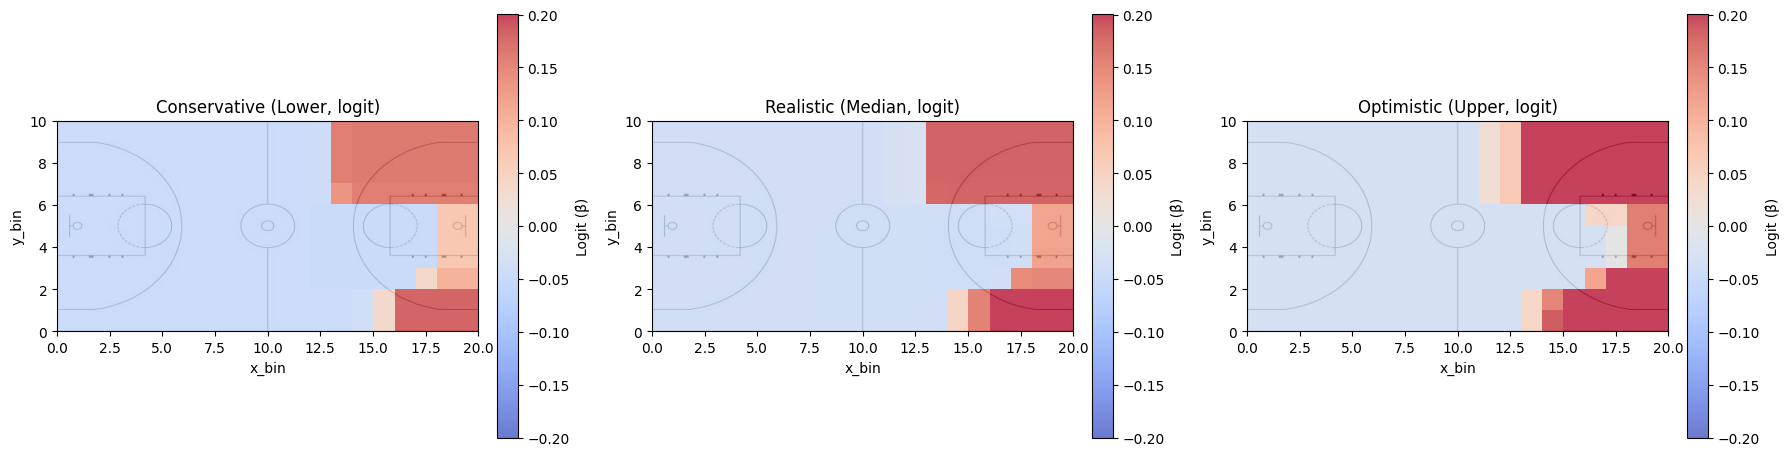

Checkpoint saved: profile_sim_results\individual_profile_like\games10_possessions92_source4370615271_grid20x10_trajectory142_outcome242_baseline0.10_mc100_alpha0.05_min100_profiles2b1671cb4b\individual_profile_summary.csv

INDIVIDUAL PROFILE | high_y_side

=== Processing single ===


Processing Bootstrap Datasets:   0%|          | 0/50 [00:00<?, ?it/s]

Simulating null responses...
Accepted 100 / 100 simulations
λ_qut (95th percentile null): 28.7077
λ_max (data): 227.1654


Processing Bootstrap Datasets: 100%|██████████| 50/50 [00:54<00:00,  1.09s/it]


λ_qut (95th percentile null): 28.7077
λ_max (observed): 227.1654
95% CI for λ_max (bootstrap): [205.6398, 245.4081]
Empirical p-value (λ_max > λ_qut): 0.0000
Plotting pointwise percentile maps at lambda = 28.7077


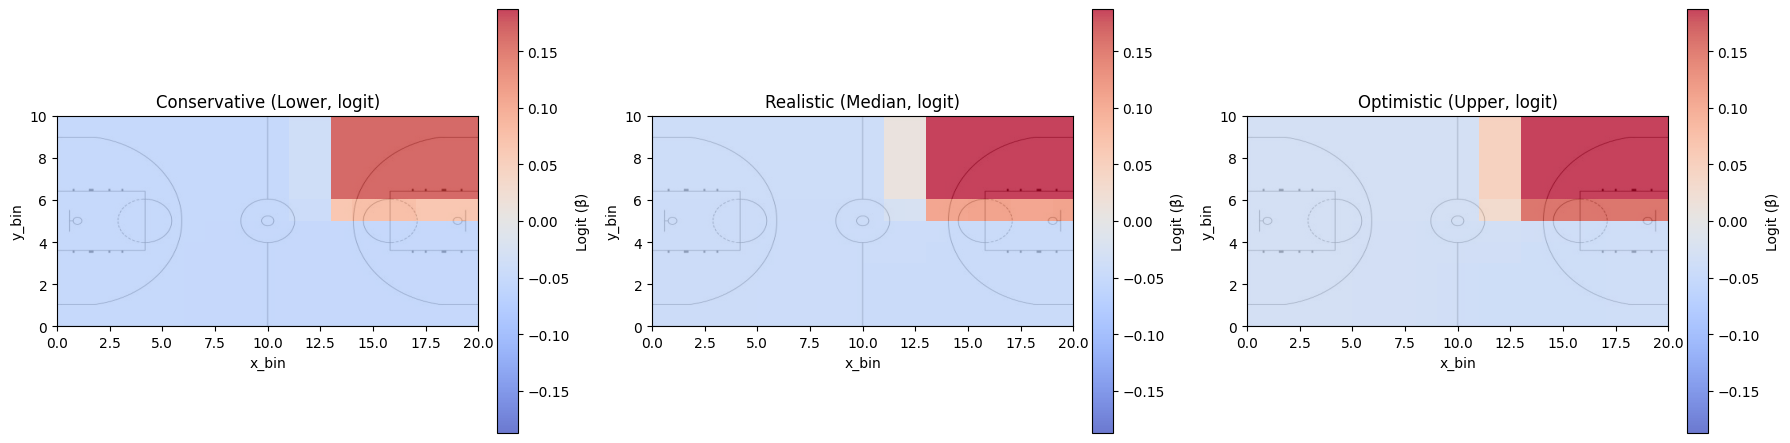

Checkpoint saved: profile_sim_results\individual_profile_like\games10_possessions92_source4370615271_grid20x10_trajectory142_outcome242_baseline0.10_mc100_alpha0.05_min100_profiles2b1671cb4b\individual_profile_summary.csv

INDIVIDUAL PROFILE | low_y_side

=== Processing single ===


Processing Bootstrap Datasets:   0%|          | 0/50 [00:00<?, ?it/s]

Simulating null responses...
Accepted 100 / 100 simulations
λ_qut (95th percentile null): 25.3795
λ_max (data): 193.8212


Processing Bootstrap Datasets: 100%|██████████| 50/50 [00:54<00:00,  1.09s/it]


λ_qut (95th percentile null): 25.3795
λ_max (observed): 193.8212
95% CI for λ_max (bootstrap): [194.2484, 222.0604]
Empirical p-value (λ_max > λ_qut): 0.0000
Plotting pointwise percentile maps at lambda = 25.3795


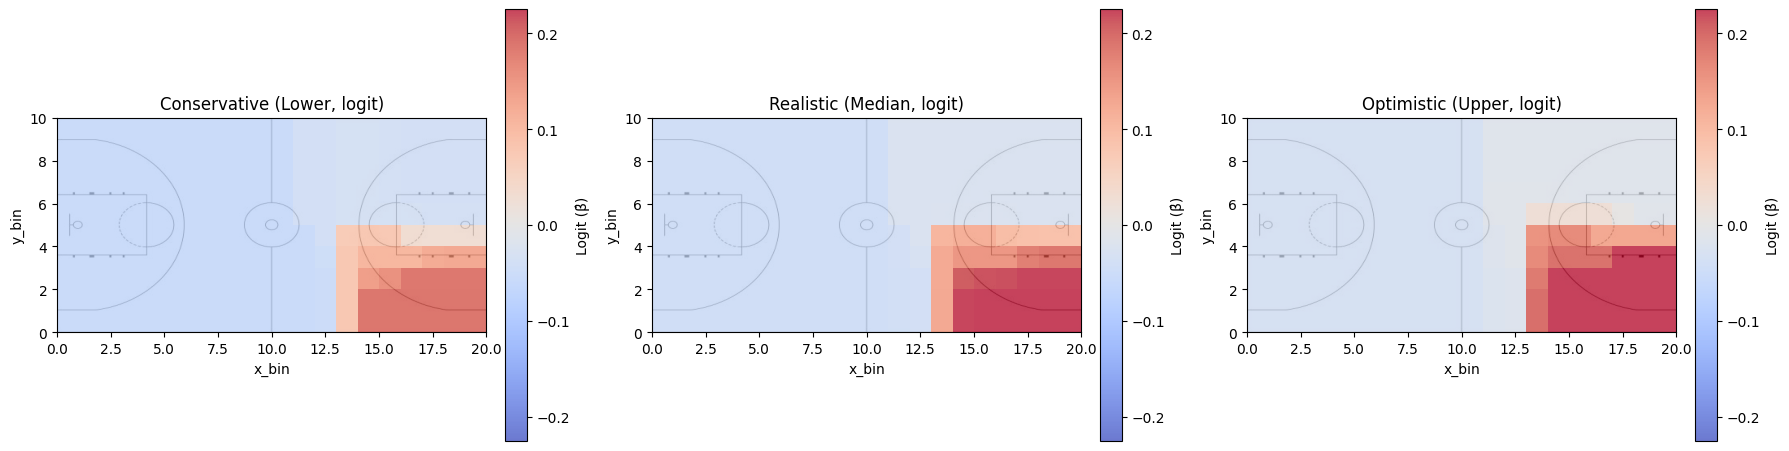

Checkpoint saved: profile_sim_results\individual_profile_like\games10_possessions92_source4370615271_grid20x10_trajectory142_outcome242_baseline0.10_mc100_alpha0.05_min100_profiles2b1671cb4b\individual_profile_summary.csv

INDIVIDUAL PROFILE | perimeter

=== Processing single ===


Processing Bootstrap Datasets:   0%|          | 0/50 [00:00<?, ?it/s]

Simulating null responses...
Accepted 100 / 100 simulations
λ_qut (95th percentile null): 26.0357
λ_max (data): 100.3988


Processing Bootstrap Datasets: 100%|██████████| 50/50 [00:54<00:00,  1.09s/it]


λ_qut (95th percentile null): 26.0357
λ_max (observed): 100.3988
95% CI for λ_max (bootstrap): [83.0800, 117.0793]
Empirical p-value (λ_max > λ_qut): 0.0000
Plotting pointwise percentile maps at lambda = 26.0357


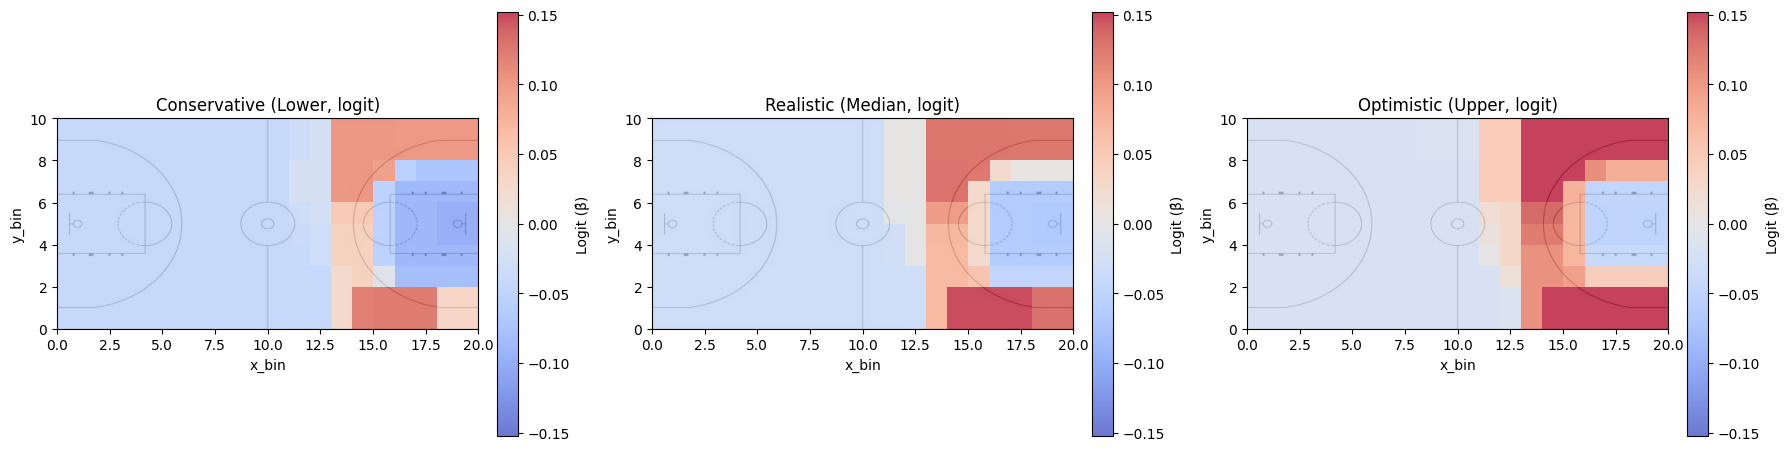

Checkpoint saved: profile_sim_results\individual_profile_like\games10_possessions92_source4370615271_grid20x10_trajectory142_outcome242_baseline0.10_mc100_alpha0.05_min100_profiles2b1671cb4b\individual_profile_summary.csv


,profile,scope,simulation_tag,seed,n_bootstraps,possessions_per_bootstrap,samples_per_possession,status,elapsed_seconds,lambda_qut,lambda_max_obs,lambda_ci_low,lambda_ci_high,p_value,reject_qut,error
4,reference,full_game,games10_possessions92_source4370615271_grid20x...,42,50,2500,250,ok,54.826399,24.536721,156.435864,129.782501,162.458424,0.0,True,None
5,high_y_side,full_game,games10_possessions92_source4370615271_grid20x...,43,50,2500,250,ok,54.739963,28.707659,227.165436,205.639838,245.408064,0.0,True,None
6,low_y_side,full_game,games10_possessions92_source4370615271_grid20x...,44,50,2500,250,ok,54.834173,25.379459,193.821179,194.248426,222.060441,0.0,True,None
7,perimeter,full_game,games10_possessions92_source4370615271_grid20x...,45,50,2500,250,ok,55.024481,26.035671,100.398821,83.079980,117.079278,0.0,True,None


In [12]:
RUN_INDIVIDUAL_PROFILE_EXPERIMENTS = True
RESUME_INDIVIDUAL_PROFILES = True
PLOT_INDIVIDUAL_PROFILE_RESULTS = True

PROFILE_LIKE_SETTINGS = {
    "n_bootstraps": 50,
    "n_possessions": 2500,
    "samples_per_possession": 250,
}

INDIVIDUAL_RESULT_DIR = RESULTS_ROOT / "individual_profile_like" / SIMULATION_TAG
INDIVIDUAL_SUMMARY_PATH = INDIVIDUAL_RESULT_DIR / "individual_profile_summary.csv"
INDIVIDUAL_FIGURE_DIR = INDIVIDUAL_RESULT_DIR / "figures"


def _individual_cache_path(profile_name):
    return INDIVIDUAL_RESULT_DIR / f"{profile_name}_profile_like.npz"


def _individual_is_complete(summary, profile_name):
    if summary.empty:
        return False
    required = {
        "profile", "status", "simulation_tag", "n_bootstraps",
        "possessions_per_bootstrap", "samples_per_possession",
    }
    if not required.issubset(summary.columns):
        return False
    rows = summary[summary["profile"] == profile_name]
    if rows.empty:
        return False
    row = rows.iloc[-1]
    return bool(
        row["status"] == "ok"
        and row["simulation_tag"] == SIMULATION_TAG
        and int(row["n_bootstraps"]) == PROFILE_LIKE_SETTINGS["n_bootstraps"]
        and int(row["possessions_per_bootstrap"]) == PROFILE_LIKE_SETTINGS["n_possessions"]
        and int(row["samples_per_possession"]) == PROFILE_LIKE_SETTINGS["samples_per_possession"]
        and _individual_cache_path(profile_name).exists()
    )


def run_individual_profile_experiments(profiles=PROFILES_TO_SIMULATE, resume=True):
    """Run and checkpoint one expensive full-game profile-like analysis per profile."""
    INDIVIDUAL_RESULT_DIR.mkdir(parents=True, exist_ok=True)
    previous = (
        pd.read_csv(INDIVIDUAL_SUMMARY_PATH)
        if resume and INDIVIDUAL_SUMMARY_PATH.exists()
        else pd.DataFrame()
    )
    new_rows = []

    for profile_name in profiles:
        if resume and _individual_is_complete(previous, profile_name):
            print(f"SKIP completed individual profile: {profile_name}")
            continue

        print("\n" + "=" * 88)
        print(f"INDIVIDUAL PROFILE | {profile_name}")
        seed = int(SIMULATION_PROFILES[profile_name]["seed"])
        np.random.seed(seed)
        started = perf_counter()
        status, error, result = "failed", None, None
        figures_before = set(plt.get_fignums())

        try:
            result = analyze_tv_logistic_single_game(
                profile_inputs[profile_name]["scopes"]["full_game"],
                game_id=None,
                n_bootstraps=PROFILE_LIKE_SETTINGS["n_bootstraps"],
                n_possessions=PROFILE_LIKE_SETTINGS["n_possessions"],
                samples_per_possession=PROFILE_LIKE_SETTINGS["samples_per_possession"],
                min_samples_required=MIN_SOURCE_SAMPLES,
                mc_null=MC_NULL,
                alpha=ALPHA,
                court_image_path=COURT_IMAGE_PATH,
                show_progress=True,
                plot_pointwise_maps=True,
                plot_lambda_distributions=False,
                seed=seed,
            )
            np.savez_compressed(
                _individual_cache_path(profile_name),
                simulation_tag=SIMULATION_TAG,
                profile=profile_name,
                seed=seed,
                n_bootstraps=PROFILE_LIKE_SETTINGS["n_bootstraps"],
                possessions_per_bootstrap=PROFILE_LIKE_SETTINGS["n_possessions"],
                samples_per_possession=PROFILE_LIKE_SETTINGS["samples_per_possession"],
                lambda_qut=result["lambda_qut"],
                lambda_max_obs=result["lambda_max_obs"],
                lambda_ci=np.asarray(result["lambda_max_ci"]),
                p_value=result["p_value"],
                lambda_null=result["lambda_null"],
                lambda_max_bootstrap=result["lambda_max_bootstrap"],
                logit_lo=result["pointwise"]["logit_lo"],
                logit_med=result["pointwise"]["logit_med"],
                logit_hi=result["pointwise"]["logit_hi"],
            )
            status = "ok"
        except Exception as exc:
            error = f"{type(exc).__name__}: {exc}"
            print(f"FAILED: {error}")
        finally:
            for figure_number in set(plt.get_fignums()).difference(figures_before):
                plt.close(figure_number)
            gc.collect()

        elapsed_seconds = perf_counter() - started
        new_rows.append({
            "profile": profile_name,
            "scope": "full_game",
            "simulation_tag": SIMULATION_TAG,
            "seed": seed,
            "n_bootstraps": PROFILE_LIKE_SETTINGS["n_bootstraps"],
            "possessions_per_bootstrap": PROFILE_LIKE_SETTINGS["n_possessions"],
            "samples_per_possession": PROFILE_LIKE_SETTINGS["samples_per_possession"],
            "status": status,
            "elapsed_seconds": elapsed_seconds,
            "lambda_qut": np.nan if result is None else result["lambda_qut"],
            "lambda_max_obs": np.nan if result is None else result["lambda_max_obs"],
            "lambda_ci_low": np.nan if result is None else result["lambda_max_ci"][0],
            "lambda_ci_high": np.nan if result is None else result["lambda_max_ci"][1],
            "p_value": np.nan if result is None else result["p_value"],
            "reject_qut": False if result is None else result["p_value"] <= ALPHA,
            "error": error,
        })
        combined = pd.concat([previous, pd.DataFrame(new_rows)], ignore_index=True)
        combined = combined.drop_duplicates("profile", keep="last")
        combined.to_csv(INDIVIDUAL_SUMMARY_PATH, index=False)
        print(f"Checkpoint saved: {INDIVIDUAL_SUMMARY_PATH}")

    combined = pd.concat([previous, pd.DataFrame(new_rows)], ignore_index=True)
    return combined.drop_duplicates("profile", keep="last")


def plot_individual_profile_result(profile_name, summary_row, output_dir):
    """Save large, fully annotated percentile maps and lambda distributions."""
    with np.load(_individual_cache_path(profile_name)) as cached:
        logit_maps = [cached["logit_lo"], cached["logit_med"], cached["logit_hi"]]
        lambda_null = cached["lambda_null"]
        lambda_bootstrap = cached["lambda_max_bootstrap"]

    planted = SIMULATION_PROFILES[profile_name]["movement_effects"]
    court = plt.imread(COURT_IMAGE_PATH)
    planted_limit = float(np.max(np.abs(planted))) or 1.0
    logit_limit = float(np.quantile(np.abs(np.stack(logit_maps)), 0.98)) or 1.0
    parameter_label = (
        f"scope=full_game\nbootstraps={int(summary_row.n_bootstraps):,} | "
        f"possessions/bootstrap={int(summary_row.possessions_per_bootstrap):,}\n"
        f"samples/possession={int(summary_row.samples_per_possession):,} | "
        f"seed={int(summary_row.seed)}\n"
        f"lambda_qut={summary_row.lambda_qut:.3f} | p={summary_row.p_value:.3f}"
    )

    fig, axes = plt.subplots(2, 2, figsize=(22, 14), constrained_layout=True)
    panels = [(planted, "Planted movement effect", planted_limit)] + [
        (logit_map, title, logit_limit)
        for logit_map, title in zip(
            logit_maps,
            ("Pointwise lower logit", "Pointwise median logit", "Pointwise upper logit"),
        )
    ]
    for ax, (data, title, limit) in zip(axes.flat, panels):
        ax.imshow(court, extent=[0, X_BINS, 0, Y_BINS], aspect="auto")
        image = ax.imshow(
            data.T, origin="lower", extent=[0, X_BINS, 0, Y_BINS],
            cmap="coolwarm", alpha=0.75, vmin=-limit, vmax=limit,
        )
        ax.set(title=f"{title}\n{parameter_label}", xlabel="x_bin", ylabel="y_bin")
        fig.colorbar(image, ax=ax, shrink=0.82)
    fig.suptitle(
        f"Individual profile-like QUT | {profile_name}\n{fixed_simulation_label()}",
        fontsize=13,
    )
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_dir / f"{profile_name}_pointwise_maps.png", dpi=210, bbox_inches="tight")
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(15, 9), constrained_layout=True)
    ax.hist(lambda_null, bins=40, alpha=0.55, label="lambda_max null", color="gray")
    ax.hist(lambda_bootstrap, bins=40, alpha=0.55, label="lambda_max bootstrap", color="skyblue")
    ax.axvline(summary_row.lambda_qut, color="black", linestyle="--", label="lambda_qut")
    ax.axvline(summary_row.lambda_max_obs, color="red", linestyle="--", label="lambda_max observed")
    ax.set(
        xlabel="lambda_max", ylabel="Frequency",
        title=(
            f"Individual profile-like QUT distributions | {profile_name}\n"
            f"{parameter_label}\n{fixed_simulation_label()}"
        ),
    )
    ax.legend()
    fig.savefig(output_dir / f"{profile_name}_lambda_distributions.png", dpi=210, bbox_inches="tight")
    plt.close(fig)


if RUN_INDIVIDUAL_PROFILE_EXPERIMENTS:
    individual_profile_summary = run_individual_profile_experiments(
        PROFILES_TO_SIMULATE, resume=RESUME_INDIVIDUAL_PROFILES
    )
else:
    individual_profile_summary = (
        pd.read_csv(INDIVIDUAL_SUMMARY_PATH)
        if INDIVIDUAL_SUMMARY_PATH.exists()
        else pd.DataFrame()
    )

if PLOT_INDIVIDUAL_PROFILE_RESULTS and not individual_profile_summary.empty:
    for row in individual_profile_summary[individual_profile_summary["status"] == "ok"].itertuples(index=False):
        plot_individual_profile_result(row.profile, row, INDIVIDUAL_FIGURE_DIR)
display(individual_profile_summary)

## 4. Exhaustive nested-prefix experiment table

The sweep is the complete Cartesian product B x P x S, with bootstrap count ordered first, then possessions, then samples. B=500 is intentionally absent. The current axes give 45 configurations for every profile/scope and 900 summary rows overall; these counts are validated dynamically when an axis is extended.

Execution is organized into 300 underlying streams: one stream for each profile, scope, possession count, and sample count. Each stream contains deterministic bootstrap slots through `max(BOOTSTRAP_VALUES)`. Smaller B results are prefixes of the same maximum-B stream, which removes seed confounding and avoids regenerating shared bootstrap work.

The first bootstrap determines `lambda_qut`, `lambda_max_obs`, and the null p-value in the current QUT implementation. Those quantities are intentionally identical across B within a stream. Bootstrap count is evaluated through CI width, bootstrap variability, and the prefix-median coefficient maps.

Stable semantic keys and the frozen `SWEEP_SERIES_ID` isolate this factorial design from the earlier one-factor checkpoints while allowing monotonic B/P/S additions to reuse compatible caches. `SWEEP_PLAN_FINGERPRINT` records the exact current axes but does not move compatible checkpoints. Old one-factor results are preserved but are not migrated because they used a different seed policy.


In [6]:
BOOTSTRAP_VALUES = (50, 100)
POSSESSION_VALUES = (1000, 2500)
SAMPLES_PER_POSSESSION_VALUES = (150, 200, 250)

if not BOOTSTRAP_VALUES or any(int(value) <= 0 for value in BOOTSTRAP_VALUES):
    raise ValueError("BOOTSTRAP_VALUES must contain positive integers.")
if tuple(sorted(set(BOOTSTRAP_VALUES))) != tuple(BOOTSTRAP_VALUES):
    raise ValueError("BOOTSTRAP_VALUES must be unique and sorted ascending.")
if 500 in BOOTSTRAP_VALUES:
    raise ValueError("This design must not execute 500-bootstrap tests.")

BASELINE_SETTINGS = {
    "n_bootstraps": 100,
    "possessions_per_bootstrap": 1000,
    "samples_per_possession": 200,
}
ANALYSIS_SCOPES = (
    "full_game",
    "quarter_1",
    "quarter_2",
    "quarter_3",
    "quarter_4",
)

SWEEP_DESIGN_VERSION = "factorial_nested_prefix_median_v1"
SEED_POLICY_VERSION = "sha256_slot_seed_v1"
MAP_ESTIMATOR = "nested_prefix_median_v1"
# Frozen compatibility namespace for monotonic B/P/S axis extensions.
# Change this ID only when old stream caches must be considered incompatible.
SWEEP_SERIES_ID = "dc0cd9facf"

_sweep_descriptor = repr(
    (
        SWEEP_DESIGN_VERSION,
        SEED_POLICY_VERSION,
        MAP_ESTIMATOR,
        BOOTSTRAP_VALUES,
        POSSESSION_VALUES,
        SAMPLES_PER_POSSESSION_VALUES,
        ANALYSIS_SCOPES,
    )
)
SWEEP_PLAN_FINGERPRINT = hashlib.sha256(
    _sweep_descriptor.encode("utf-8")
).hexdigest()[:10]
SWEEP_TAG = f"{SIMULATION_TAG}_plan{SWEEP_SERIES_ID}"
print(
    f"Sweep series={SWEEP_SERIES_ID} | "
    f"current plan fingerprint={SWEEP_PLAN_FINGERPRINT} | "
    f"max B={max(BOOTSTRAP_VALUES):,}"
)


def _stable_uint32_seed(*parts):
    payload = "|".join(map(str, parts)).encode("utf-8")
    return int.from_bytes(hashlib.sha256(payload).digest()[:4], "little")


def bootstrap_slot_seed(scope, possessions, samples, bootstrap_index):
    """Pair trajectory resampling across profiles, independently of B."""
    return _stable_uint32_seed(
        SIMULATION_TAG,
        SWEEP_DESIGN_VERSION,
        SEED_POLICY_VERSION,
        "bootstrap",
        scope,
        int(possessions),
        int(samples),
        int(bootstrap_index),
    )


def qut_null_seed(profile, scope, possessions, samples):
    """Give every underlying stream an explicit reproducible null RNG."""
    return _stable_uint32_seed(
        SIMULATION_TAG,
        SWEEP_DESIGN_VERSION,
        SEED_POLICY_VERSION,
        "null",
        profile,
        scope,
        int(possessions),
        int(samples),
    )


def configuration_key(n_bootstraps, possessions, samples):
    return f"b{int(n_bootstraps):03d}_p{int(possessions):05d}_s{int(samples):03d}"


def bootstrap_group_key(possessions, samples):
    return f"p{int(possessions):05d}_s{int(samples):03d}"


def build_unique_configurations():
    """Return the exhaustive B x P x S design in ascending display order."""
    rows = []
    for config_id, (n_bootstraps, possessions, samples) in enumerate(
        product(
            BOOTSTRAP_VALUES,
            POSSESSION_VALUES,
            SAMPLES_PER_POSSESSION_VALUES,
        )
    ):
        settings = {
            "config_id": int(config_id),
            "config_key": configuration_key(n_bootstraps, possessions, samples),
            "bootstrap_group_key": bootstrap_group_key(possessions, samples),
            "design": "full_factorial_nested_prefix",
            "n_bootstraps": int(n_bootstraps),
            "possessions_per_bootstrap": int(possessions),
            "samples_per_possession": int(samples),
        }
        settings["is_baseline"] = all(
            settings[name] == value for name, value in BASELINE_SETTINGS.items()
        )
        settings["is_individual_profile_like"] = bool(
            n_bootstraps == 100 and possessions == 10000 and samples == 150
        )
        rows.append(settings)
    return pd.DataFrame(rows)


def build_experiment_plan(profiles, scopes=ANALYSIS_SCOPES):
    configurations = build_unique_configurations()
    rows = []
    for profile_name in profiles:
        for config in configurations.itertuples(index=False):
            for scope in scopes:
                stream_id = (
                    f"{profile_name}__{scope}__{config.bootstrap_group_key}"
                )
                rows.append(
                    {
                        "run_id": (
                            f"{profile_name}__{scope}__{config.config_key}"
                        ),
                        "stream_id": stream_id,
                        "profile": profile_name,
                        "scope": scope,
                        **config._asdict(),
                        "bootstrap_seed": bootstrap_slot_seed(
                            scope,
                            config.possessions_per_bootstrap,
                            config.samples_per_possession,
                            0,
                        ),
                        "null_seed": qut_null_seed(
                            profile_name,
                            scope,
                            config.possessions_per_bootstrap,
                            config.samples_per_possession,
                        ),
                    }
                )
    return pd.DataFrame(rows)


def validate_experiment_plan(plan):
    expected = set(
        product(
            BOOTSTRAP_VALUES,
            POSSESSION_VALUES,
            SAMPLES_PER_POSSESSION_VALUES,
        )
    )
    actual = set(
        plan[
            [
                "n_bootstraps",
                "possessions_per_bootstrap",
                "samples_per_possession",
            ]
        ].itertuples(index=False, name=None)
    )
    if actual != expected:
        raise AssertionError("The configuration table is not the complete B x P x S grid.")
    if (plan["n_bootstraps"] == 500).any():
        raise AssertionError("A forbidden 500-bootstrap row entered the plan.")
    expected_rows = (
        len(PROFILES_TO_SIMULATE) * len(ANALYSIS_SCOPES) * len(expected)
    )
    if len(plan) != expected_rows:
        raise AssertionError(
            f"The exhaustive plan must contain {expected_rows:,} rows."
        )
    if not plan["run_id"].is_unique:
        raise AssertionError("run_id values must be unique.")
    if plan.duplicated(
        [
            "profile",
            "scope",
            "n_bootstraps",
            "possessions_per_bootstrap",
            "samples_per_possession",
        ]
    ).any():
        raise AssertionError("The plan contains duplicate factorial cells.")
    per_bootstrap = plan.groupby(
        ["profile", "scope", "n_bootstraps"], observed=False
    ).size()
    if not per_bootstrap.eq(
        len(POSSESSION_VALUES) * len(SAMPLES_PER_POSSESSION_VALUES)
    ).all():
        raise AssertionError(
            "Every B value must contain the complete P x S product."
        )
    if plan["stream_id"].nunique() != (
        len(PROFILES_TO_SIMULATE)
        * len(ANALYSIS_SCOPES)
        * len(POSSESSION_VALUES)
        * len(SAMPLES_PER_POSSESSION_VALUES)
    ):
        raise AssertionError("The plan has the wrong nested-stream count.")
    return True


experiment_plan = build_experiment_plan(PROFILES_TO_SIMULATE)
validate_experiment_plan(experiment_plan)
display(build_unique_configurations())
display(
    experiment_plan.groupby(
        ["profile", "scope", "n_bootstraps"], observed=False
    ).size().rename("possession_sample_combinations").reset_index()
)


Sweep series=dc0cd9facf | current plan fingerprint=34bcedd17b | max B=100


,config_id,config_key,bootstrap_group_key,design,n_bootstraps,possessions_per_bootstrap,samples_per_possession,is_baseline,is_individual_profile_like
0,0,b050_p01000_s150,p01000_s150,full_factorial_nested_prefix,50,1000,150,False,False
1,1,b050_p01000_s200,p01000_s200,full_factorial_nested_prefix,50,1000,200,False,False
2,2,b050_p01000_s250,p01000_s250,full_factorial_nested_prefix,50,1000,250,False,False
3,3,b050_p02500_s150,p02500_s150,full_factorial_nested_prefix,50,2500,150,False,False
4,4,b050_p02500_s200,p02500_s200,full_factorial_nested_prefix,50,2500,200,False,False
5,5,b050_p02500_s250,p02500_s250,full_factorial_nested_prefix,50,2500,250,False,False
6,6,b100_p01000_s150,p01000_s150,full_factorial_nested_prefix,100,1000,150,False,False
7,7,b100_p01000_s200,p01000_s200,full_factorial_nested_prefix,100,1000,200,True,False
8,8,b100_p01000_s250,p01000_s250,full_factorial_nested_prefix,100,1000,250,False,False
9,9,b100_p02500_s150,p02500_s150,full_factorial_nested_prefix,100,2500,150,False,False


,profile,scope,n_bootstraps,possession_sample_combinations
0,high_y_side,full_game,50,6
1,high_y_side,full_game,100,6
2,high_y_side,quarter_1,50,6
3,high_y_side,quarter_1,100,6
4,high_y_side,quarter_2,50,6
5,high_y_side,quarter_2,100,6
6,high_y_side,quarter_3,50,6
7,high_y_side,quarter_3,100,6
8,high_y_side,quarter_4,50,6
9,high_y_side,quarter_4,100,6


In [7]:
def select_experiment_rows(
    plan,
    profiles=None,
    scopes=None,
    designs=None,
    run_ids=None,
):
    """Filter the plan with explicit, validated selections."""
    selected = plan.copy()
    filters = {
        "profile": profiles,
        "scope": scopes,
        "design": designs,
        "run_id": run_ids,
    }
    for column, values in filters.items():
        if values is None:
            continue
        values = [values] if isinstance(values, str) else list(values)
        unknown = set(values).difference(plan[column].unique())
        if unknown:
            raise ValueError(
                f"Unknown {column} value(s): {sorted(unknown)}. "
                f"Valid values: {sorted(plan[column].unique())}"
            )
        selected = selected[selected[column].isin(values)]
    if selected.empty:
        raise ValueError("The selection contains no experiment rows.")
    return selected.reset_index(drop=True)


def _atomic_to_csv(frame, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + ".tmp")
    frame.to_csv(temporary, index=False)
    for attempt in range(20):
        try:
            temporary.replace(path)
            break
        except PermissionError:
            if attempt == 19:
                raise
            sleep(0.05 * (attempt + 1))


def _atomic_savez(path, **arrays):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_name(path.name + ".tmp.npz")
    np.savez_compressed(temporary, **arrays)
    for attempt in range(20):
        try:
            temporary.replace(path)
            break
        except PermissionError:
            if attempt == 19:
                raise
            sleep(0.05 * (attempt + 1))


def nested_stream_cache_path(cache_dir, profile, scope, group_key):
    return Path(cache_dir) / profile / f"{profile}__{scope}__{group_key}.npz"


def completed_run_ids_for_plan(summary, plan):
    """Return successful rows matching this exact nested design and seed policy."""
    required = {
        "run_id",
        "status",
        "simulation_tag",
        "sweep_tag",
        "sweep_design_version",
        "seed_policy_version",
        "map_estimator",
        "profile",
        "scope",
        "config_key",
        "bootstrap_group_key",
        "n_bootstraps",
        "possessions_per_bootstrap",
        "samples_per_possession",
        "bootstrap_seed",
        "null_seed",
    }
    if summary.empty or not required.issubset(summary.columns):
        return set()
    lookup = plan.set_index("run_id")
    completed = set()
    for row in summary[summary["status"] == "ok"].itertuples(index=False):
        if row.run_id not in lookup.index:
            continue
        planned = lookup.loc[row.run_id]
        matches = (
            row.simulation_tag == SIMULATION_TAG
            and row.sweep_tag == SWEEP_TAG
            and row.sweep_design_version == SWEEP_DESIGN_VERSION
            and row.seed_policy_version == SEED_POLICY_VERSION
            and row.map_estimator == MAP_ESTIMATOR
            and row.profile == planned.profile
            and row.scope == planned.scope
            and row.config_key == planned.config_key
            and row.bootstrap_group_key == planned.bootstrap_group_key
            and int(row.n_bootstraps) == int(planned.n_bootstraps)
            and int(row.possessions_per_bootstrap)
            == int(planned.possessions_per_bootstrap)
            and int(row.samples_per_possession)
            == int(planned.samples_per_possession)
            and int(row.bootstrap_seed) == int(planned.bootstrap_seed)
            and int(row.null_seed) == int(planned.null_seed)
        )
        if matches:
            completed.add(row.run_id)
    return completed


def _empty_nested_stream_state(max_bootstraps=None):
    max_bootstraps = int(
        max(BOOTSTRAP_VALUES) if max_bootstraps is None else max_bootstraps
    )
    return {
        "lambda_qut": np.nan,
        "lambda_max_obs": np.nan,
        "p_value": np.nan,
        "lambda_null": np.full(MC_NULL, np.nan, dtype=float),
        "lambda_max": np.full(max_bootstraps, np.nan, dtype=float),
        "lambda_done": np.zeros(max_bootstraps, dtype=bool),
        "beta_maps": np.full(
            (max_bootstraps, X_BINS, Y_BINS),
            np.nan,
            dtype=np.float32,
        ),
        "map_done": np.zeros(max_bootstraps, dtype=bool),
        "slot_elapsed_seconds": np.zeros(max_bootstraps, dtype=float),
    }


def _stream_metadata(
    profile, scope, possessions, samples, bootstrap_values=None
):
    bootstrap_values = tuple(
        BOOTSTRAP_VALUES if bootstrap_values is None else bootstrap_values
    )
    if (
        not bootstrap_values
        or tuple(sorted(set(bootstrap_values))) != bootstrap_values
        or any(int(value) <= 0 for value in bootstrap_values)
    ):
        raise ValueError("bootstrap_values must be positive, unique, and sorted.")
    return {
        "simulation_tag": SIMULATION_TAG,
        "sweep_tag": SWEEP_TAG,
        "sweep_design_version": SWEEP_DESIGN_VERSION,
        "seed_policy_version": SEED_POLICY_VERSION,
        "map_estimator": MAP_ESTIMATOR,
        "profile": profile,
        "scope": scope,
        "bootstrap_group_key": bootstrap_group_key(possessions, samples),
        "possessions_per_bootstrap": int(possessions),
        "samples_per_possession": int(samples),
        "max_bootstraps": int(max(bootstrap_values)),
        "bootstrap_values": np.asarray(bootstrap_values, dtype=np.int64),
        "mc_null": int(MC_NULL),
        "alpha": float(ALPHA),
        "min_source_samples": int(MIN_SOURCE_SAMPLES),
        "null_seed": int(qut_null_seed(profile, scope, possessions, samples)),
    }


def _save_nested_stream_state(path, metadata, state):
    _atomic_savez(path, **metadata, **state)


def _load_nested_stream_state(path, expected_metadata):
    path = Path(path)
    expected_max = int(expected_metadata["max_bootstraps"])
    if not path.exists():
        return _empty_nested_stream_state(expected_max), False
    try:
        with np.load(path, allow_pickle=False) as cached:
            scalar_checks = (
                "simulation_tag",
                "sweep_tag",
                "sweep_design_version",
                "seed_policy_version",
                "map_estimator",
                "profile",
                "scope",
                "bootstrap_group_key",
                "possessions_per_bootstrap",
                "samples_per_possession",
                "mc_null",
                "alpha",
                "min_source_samples",
                "null_seed",
            )
            for key in scalar_checks:
                if key not in cached:
                    return _empty_nested_stream_state(expected_max), False
                actual = cached[key].item()
                expected = expected_metadata[key]
                if isinstance(expected, float):
                    if not np.isclose(float(actual), expected):
                        return _empty_nested_stream_state(expected_max), False
                elif str(actual) != str(expected):
                    return _empty_nested_stream_state(expected_max), False
            required = {
                "max_bootstraps",
                "bootstrap_values",
                "lambda_qut",
                "lambda_max_obs",
                "p_value",
                "lambda_null",
                "lambda_max",
                "lambda_done",
                "beta_maps",
                "map_done",
                "slot_elapsed_seconds",
            }
            if not required.issubset(cached.files):
                return _empty_nested_stream_state(expected_max), False
            cached_max = int(cached["max_bootstraps"].item())
            cached_prefixes = np.asarray(
                cached["bootstrap_values"], dtype=int
            )
            if (
                cached_prefixes.ndim != 1
                or len(cached_prefixes) == 0
                or np.any(cached_prefixes <= 0)
                or np.any(np.diff(cached_prefixes) <= 0)
                or int(cached_prefixes[-1]) != cached_max
            ):
                return _empty_nested_stream_state(expected_max), False
            # Prefix labels are reporting choices, not part of slot generation.
            # Removing B=10 or adding B=75 below an existing maximum leaves
            # every deterministic cached slot valid. Only shrinking the cached
            # maximum is deliberately rejected in this sweep series.
            if cached_max > expected_max:
                raise RuntimeError(
                    "The current bootstrap grid reduces the cached maximum. "
                    "Restore that maximum or use a new SWEEP_SERIES_ID."
                )
            vector_shapes = {
                "lambda_max": (cached_max,),
                "lambda_done": (cached_max,),
                "map_done": (cached_max,),
                "slot_elapsed_seconds": (cached_max,),
                "beta_maps": (cached_max, X_BINS, Y_BINS),
            }
            if any(cached[key].shape != shape for key, shape in vector_shapes.items()):
                return _empty_nested_stream_state(expected_max), False
            if cached["lambda_null"].shape != (MC_NULL,):
                return _empty_nested_stream_state(expected_max), False
            state = _empty_nested_stream_state(expected_max)
            state["lambda_qut"] = float(cached["lambda_qut"].item())
            state["lambda_max_obs"] = float(
                cached["lambda_max_obs"].item()
            )
            state["p_value"] = float(cached["p_value"].item())
            state["lambda_null"] = cached["lambda_null"].copy()
            for key in (
                "lambda_max",
                "lambda_done",
                "map_done",
                "slot_elapsed_seconds",
            ):
                state[key][:cached_max] = cached[key]
            state["beta_maps"][:cached_max] = cached["beta_maps"]
        return state, True
    except RuntimeError:
        raise
    except Exception:
        return _empty_nested_stream_state(expected_max), False


def _single_bootstrap_dataset(qut_input, possessions, samples, slot_seed):
    return next(
        iter_bootstrapped_datasets(
            qut_input,
            n_bootstraps=1,
            n_possessions_per_bootstrap=int(possessions),
            samples_per_possession=int(samples),
            min_samples_required=MIN_SOURCE_SAMPLES,
            seed=int(slot_seed),
            show_progress=False,
        )
    )


def run_nested_qut_stream(
    qut_input,
    profile,
    scope,
    possessions,
    samples,
    cache_path,
    show_progress=True,
    bootstrap_values=None,
):
    """Compute/resume one stream through the configured maximum B."""
    bootstrap_values = tuple(
        BOOTSTRAP_VALUES if bootstrap_values is None else bootstrap_values
    )
    if max(bootstrap_values) > 500:
        raise RuntimeError("Nested runner is capped at 500 bootstraps.")

    target_bootstraps = int(max(bootstrap_values))
    metadata = _stream_metadata(
        profile,
        scope,
        possessions,
        samples,
        bootstrap_values=bootstrap_values,
    )
    state, cache_valid = _load_nested_stream_state(cache_path, metadata)
    if cache_valid:
        completed = int((state["lambda_done"] & state["map_done"]).sum())
        print(
            f"Validated stream cache: {completed}/{target_bootstraps} "
            "slots complete"
        )

    for bootstrap_index in range(target_bootstraps):
        needs_lambda = not bool(state["lambda_done"][bootstrap_index])
        needs_map = not bool(state["map_done"][bootstrap_index])
        if not needs_lambda and not needs_map:
            continue

        slot_started = perf_counter()
        slot_seed = bootstrap_slot_seed(
            scope, possessions, samples, bootstrap_index
        )
        df_boot = _single_bootstrap_dataset(
            qut_input, possessions, samples, slot_seed
        )
        try:
            if needs_lambda:
                X_boot, y_boot, D_TV = grid(df_boot)
                if bootstrap_index == 0:
                    null_rng = np.random.default_rng(metadata["null_seed"])
                    lambda_qut_value, lambda_max_obs, lambda_null = lambda_qut(
                        X_boot,
                        y_boot,
                        D_TV,
                        MC=MC_NULL,
                        random_state=null_rng,
                    )
                    lambda_null = np.asarray(lambda_null, dtype=float)
                    if len(lambda_null) != MC_NULL:
                        raise RuntimeError(
                            f"Expected {MC_NULL} null draws, got {len(lambda_null)}."
                        )
                    state["lambda_qut"] = float(lambda_qut_value)
                    state["lambda_max_obs"] = float(lambda_max_obs)
                    state["lambda_null"] = lambda_null
                    state["p_value"] = float(
                        np.mean(lambda_null >= float(lambda_max_obs))
                    )
                    state["lambda_max"][bootstrap_index] = float(lambda_max_obs)
                else:
                    _, lambda_max_value = solve_infinity_norm(
                        y_boot,
                        X_boot,
                        D_TV,
                        project_grad_h=True,
                    )
                    if not np.isfinite(lambda_max_value):
                        raise RuntimeError(
                            f"Non-finite lambda_max at slot {bootstrap_index}."
                        )
                    state["lambda_max"][bootstrap_index] = float(
                        lambda_max_value
                    )
                state["lambda_done"][bootstrap_index] = True
                del X_boot, y_boot, D_TV

            if needs_map:
                if not np.isfinite(state["lambda_qut"]):
                    raise RuntimeError("lambda_qut is unavailable for beta fitting.")
                beta_map = tv_logistic_regression_heatmap(
                    df_boot,
                    lambda_tv=float(state["lambda_qut"]),
                    grid_width=X_BINS,
                    grid_height=Y_BINS,
                    court_image_path=COURT_IMAGE_PATH,
                    plot=False,
                )
                if not np.isfinite(beta_map).all():
                    raise RuntimeError(
                        f"Non-finite beta map at slot {bootstrap_index}."
                    )
                state["beta_maps"][bootstrap_index] = np.asarray(
                    beta_map, dtype=np.float32
                )
                state["map_done"][bootstrap_index] = True
        finally:
            state["slot_elapsed_seconds"][bootstrap_index] += (
                perf_counter() - slot_started
            )
            _save_nested_stream_state(cache_path, metadata, state)
            del df_boot
            gc.collect()

        completed = bootstrap_index + 1
        if show_progress and (
            completed in bootstrap_values or completed % 10 == 0
        ):
            print(
                f"  nested slot {completed:3d}/{target_bootstraps} complete | "
                f"P={int(possessions):,}, S={int(samples):,}"
            )

    if not state["lambda_done"].all() or not state["map_done"].all():
        raise RuntimeError("Nested stream cache is incomplete after execution.")
    return state


def _prefix_summary_rows(plan_rows, state, qut_input):
    rows = []
    for planned in plan_rows.sort_values("n_bootstraps").itertuples(index=False):
        n_bootstraps = int(planned.n_bootstraps)
        lambda_values = np.asarray(state["lambda_max"][:n_bootstraps], dtype=float)
        maps = np.asarray(state["beta_maps"][:n_bootstraps], dtype=float)
        if not np.isfinite(lambda_values).all() or not np.isfinite(maps).all():
            raise RuntimeError(
                f"Prefix B={n_bootstraps} contains an incomplete slot."
            )
        ci_low, ci_high = np.quantile(
            lambda_values, [ALPHA / 2, 1 - ALPHA / 2]
        )
        rows.append(
            {
                **planned._asdict(),
                "simulation_tag": SIMULATION_TAG,
                "sweep_tag": SWEEP_TAG,
                "sweep_design_version": SWEEP_DESIGN_VERSION,
                "seed_policy_version": SEED_POLICY_VERSION,
                "map_estimator": MAP_ESTIMATOR,
                "source_possessions": int(
                    qut_input["possession_number"].nunique()
                ),
                "status": "ok",
                "elapsed_seconds": float(
                    state["slot_elapsed_seconds"][:n_bootstraps].sum()
                ),
                "lambda_qut": float(state["lambda_qut"]),
                "lambda_max_obs": float(state["lambda_max_obs"]),
                "lambda_ci_low": float(ci_low),
                "lambda_ci_high": float(ci_high),
                "lambda_ci_width": float(ci_high - ci_low),
                "lambda_bootstrap_mean": float(lambda_values.mean()),
                "lambda_bootstrap_std": float(lambda_values.std(ddof=1)),
                "bootstrap_draws_requested": n_bootstraps,
                "bootstrap_draws_successful": n_bootstraps,
                "p_value": float(state["p_value"]),
                "reject_qut": bool(state["p_value"] <= ALPHA),
                "error": None,
            }
        )
    return rows


def run_nested_qut_experiments(
    profile_data,
    selected_plan,
    cache_dir,
    checkpoint_path=None,
    resume=True,
    continue_on_error=True,
    show_progress=True,
    bootstrap_values=None,
):
    """Run one stream per profile/scope/P/S and checkpoint all B prefixes."""
    requested_bootstrap_values = (
        None if bootstrap_values is None else tuple(bootstrap_values)
    )
    checkpoint_path = (
        Path(checkpoint_path) if checkpoint_path is not None else None
    )
    previous = pd.DataFrame()
    if checkpoint_path is not None and resume and checkpoint_path.exists():
        previous = pd.read_csv(checkpoint_path)
    completed = completed_run_ids_for_plan(previous, selected_plan)
    new_rows = []
    cache_paths = {}

    group_columns = [
        "profile",
        "scope",
        "bootstrap_group_key",
        "possessions_per_bootstrap",
        "samples_per_possession",
    ]
    grouped = list(selected_plan.groupby(group_columns, sort=False, observed=False))
    for stream_number, (group_values, plan_rows) in enumerate(grouped, start=1):
        profile, scope, group_key, possessions, samples = group_values
        if set(plan_rows["run_id"]).issubset(completed):
            print(f"SKIP completed stream: {profile}__{scope}__{group_key}")
            continue
        print("\n" + "=" * 88)
        print(
            f"STREAM {stream_number}/{len(grouped)} | "
            f"{profile} / {scope} / {group_key}"
        )
        stream_bootstrap_values = (
            tuple(sorted(plan_rows["n_bootstraps"].astype(int).unique()))
            if requested_bootstrap_values is None
            else requested_bootstrap_values
        )
        prefix_label = ",".join(map(str, stream_bootstrap_values))
        print(
            f"Nested design: B prefixes={prefix_label} | "
            f"P={int(possessions):,} | S={int(samples):,}"
        )
        cache_path = nested_stream_cache_path(
            cache_dir, profile, scope, group_key
        )
        cache_paths[f"{profile}__{scope}__{group_key}"] = cache_path
        qut_input = profile_data[profile]["scopes"][scope]
        try:
            state = run_nested_qut_stream(
                qut_input,
                profile,
                scope,
                int(possessions),
                int(samples),
                cache_path,
                show_progress=show_progress,
                bootstrap_values=stream_bootstrap_values,
            )
            new_rows.extend(_prefix_summary_rows(plan_rows, state, qut_input))
        except Exception as exc:
            error = f"{type(exc).__name__}: {exc}"
            print(f"FAILED STREAM: {error}")
            for planned in plan_rows.itertuples(index=False):
                new_rows.append(
                    {
                        **planned._asdict(),
                        "simulation_tag": SIMULATION_TAG,
                        "sweep_tag": SWEEP_TAG,
                        "sweep_design_version": SWEEP_DESIGN_VERSION,
                        "seed_policy_version": SEED_POLICY_VERSION,
                        "map_estimator": MAP_ESTIMATOR,
                        "source_possessions": int(
                            qut_input["possession_number"].nunique()
                        ),
                        "status": "failed",
                        "elapsed_seconds": np.nan,
                        "lambda_qut": np.nan,
                        "lambda_max_obs": np.nan,
                        "lambda_ci_low": np.nan,
                        "lambda_ci_high": np.nan,
                        "lambda_ci_width": np.nan,
                        "lambda_bootstrap_mean": np.nan,
                        "lambda_bootstrap_std": np.nan,
                        "bootstrap_draws_requested": int(
                            planned.n_bootstraps
                        ),
                        "bootstrap_draws_successful": 0,
                        "p_value": np.nan,
                        "reject_qut": False,
                        "error": error,
                    }
                )
            if not continue_on_error:
                raise

        if checkpoint_path is not None:
            combined = pd.concat(
                [previous, pd.DataFrame(new_rows)], ignore_index=True
            ).drop_duplicates("run_id", keep="last")
            _atomic_to_csv(combined, checkpoint_path)
            print(f"Checkpoint saved: {checkpoint_path}")
        plt.close("all")
        gc.collect()

    combined = pd.concat(
        [previous, pd.DataFrame(new_rows)], ignore_index=True
    )
    if not combined.empty:
        combined = combined.drop_duplicates("run_id", keep="last")
    return combined, cache_paths


In [8]:
RUN_PARAMETER_SWEEP = False
# None runs every unfinished P/S stream. Use an integer for shorter notebook batches.
STREAM_SETTINGS_PER_PROFILE_PER_BATCH = None
RESUME_FROM_CHECKPOINT = True

SWEEP_RESULT_DIR = RESULTS_ROOT / "sweeps" / SWEEP_TAG
NESTED_STREAM_CACHE_DIR = RESULTS_ROOT / "nested_streams" / SWEEP_TAG


def sweep_checkpoint_path(profile_name):
    return SWEEP_RESULT_DIR / f"{profile_name}_qut_summary.csv"


def load_sweep_summary(
    profiles=PROFILES_TO_SIMULATE,
    plan=None,
    include_history=False,
):
    """Load checkpoints, returning only the active plan unless requested."""
    summaries = []
    for profile_name in profiles:
        path = sweep_checkpoint_path(profile_name)
        if path.exists():
            summaries.append(pd.read_csv(path))
    if not summaries:
        return pd.DataFrame()
    combined = pd.concat(summaries, ignore_index=True)
    if include_history:
        return combined
    active_plan = experiment_plan if plan is None else plan
    active_run_ids = set(active_plan["run_id"])
    return combined[combined["run_id"].isin(active_run_ids)].copy()


def validate_exhaustive_summary(summary, require_complete=False):
    if summary.empty:
        if require_complete:
            raise AssertionError("The exhaustive summary is empty.")
        return {
            "completed": 0,
            "expected": len(experiment_plan),
            "historical_rows_ignored": 0,
        }
    expected_run_ids = set(experiment_plan["run_id"])
    historical_rows_ignored = int(
        (~summary["run_id"].isin(expected_run_ids)).sum()
    )
    current = summary[summary["run_id"].isin(expected_run_ids)].copy()
    completed = completed_run_ids_for_plan(current, experiment_plan)
    successful = current[
        current["run_id"].isin(completed)
    ].drop_duplicates("run_id", keep="last")
    if (successful["n_bootstraps"] == 500).any():
        raise AssertionError("A 500-bootstrap result entered the new sweep.")
    if not successful.empty:
        paired = successful.groupby(
            ["profile", "scope", "bootstrap_group_key"], observed=False
        )
        for _, rows in paired:
            if set(rows["n_bootstraps"]) == set(BOOTSTRAP_VALUES):
                for metric in ("lambda_qut", "lambda_max_obs", "p_value"):
                    if rows[metric].nunique(dropna=False) != 1:
                        raise AssertionError(
                            f"Nested prefixes disagree on {metric}."
                        )
    if require_complete:
        if len(completed) != len(experiment_plan):
            raise AssertionError(
                f"Expected {len(experiment_plan)} successful rows; got {len(completed)}."
            )
        if len(successful) != len(experiment_plan):
            raise AssertionError("The completed summary contains duplicate rows.")
    return {
        "completed": len(completed),
        "expected": len(experiment_plan),
        "historical_rows_ignored": historical_rows_ignored,
    }


SELECTED_PROFILES = PROFILES_TO_SIMULATE
SELECTED_SCOPES = ANALYSIS_SCOPES
SELECTED_DESIGNS = ("full_factorial_nested_prefix",)
SELECTED_RUN_IDS = None

selected_experiment_plan = select_experiment_rows(
    experiment_plan,
    profiles=SELECTED_PROFILES,
    scopes=SELECTED_SCOPES,
    designs=SELECTED_DESIGNS,
    run_ids=SELECTED_RUN_IDS,
)

batch_plans = []
for profile_name in SELECTED_PROFILES:
    profile_plan = selected_experiment_plan[
        selected_experiment_plan["profile"] == profile_name
    ].copy()
    checkpoint_path = sweep_checkpoint_path(profile_name)
    checkpoint = (
        pd.read_csv(checkpoint_path)
        if RESUME_FROM_CHECKPOINT and checkpoint_path.exists()
        else pd.DataFrame()
    )
    completed = completed_run_ids_for_plan(checkpoint, profile_plan)
    pending = profile_plan[~profile_plan["run_id"].isin(completed)].copy()
    pending_group_keys = list(
        dict.fromkeys(pending["bootstrap_group_key"].tolist())
    )
    if STREAM_SETTINGS_PER_PROFILE_PER_BATCH is not None:
        pending_group_keys = pending_group_keys[
            : int(STREAM_SETTINGS_PER_PROFILE_PER_BATCH)
        ]
    batch = profile_plan[
        profile_plan["bootstrap_group_key"].isin(pending_group_keys)
    ].copy()
    batch_plans.append(batch)
    print(
        f"{profile_name}: completed={len(completed)}/{len(profile_plan)} | "
        f"pending streams={pending['stream_id'].nunique()} | "
        f"this batch streams={batch['stream_id'].nunique()}"
    )

next_experiment_batch = pd.concat(batch_plans, ignore_index=True)
display(next_experiment_batch)

stream_cache_paths = {}
if RUN_PARAMETER_SWEEP and not next_experiment_batch.empty:
    for profile_name in SELECTED_PROFILES:
        profile_batch = next_experiment_batch[
            next_experiment_batch["profile"] == profile_name
        ].copy()
        if profile_batch.empty:
            continue
        _, profile_cache_paths = run_nested_qut_experiments(
            profile_inputs,
            profile_batch,
            cache_dir=NESTED_STREAM_CACHE_DIR,
            checkpoint_path=sweep_checkpoint_path(profile_name),
            resume=RESUME_FROM_CHECKPOINT,
            continue_on_error=True,
            show_progress=True,
        )
        stream_cache_paths.update(profile_cache_paths)
elif next_experiment_batch.empty:
    print("All exhaustive nested-prefix streams are complete.")
else:
    print("Set RUN_PARAMETER_SWEEP = True to run the displayed streams.")

experiment_summary = load_sweep_summary(SELECTED_PROFILES)
progress = validate_exhaustive_summary(
    experiment_summary,
    require_complete=next_experiment_batch.empty,
)
print(f"Validated exhaustive progress: {progress['completed']}/{progress['expected']}")
if not experiment_summary.empty:
    _atomic_to_csv(
        experiment_summary,
        SWEEP_RESULT_DIR / "all_profiles_qut_summary.csv",
    )
display(experiment_summary)


reference: completed=60/60 | pending streams=0 | this batch streams=0
high_y_side: completed=60/60 | pending streams=0 | this batch streams=0
low_y_side: completed=60/60 | pending streams=0 | this batch streams=0
perimeter: completed=60/60 | pending streams=0 | this batch streams=0


,run_id,stream_id,profile,scope,config_id,config_key,bootstrap_group_key,design,n_bootstraps,possessions_per_bootstrap,samples_per_possession,is_baseline,is_individual_profile_like,bootstrap_seed,null_seed


All exhaustive nested-prefix streams are complete.
Validated exhaustive progress: 240/240


,run_id,stream_id,profile,scope,config_id,config_key,bootstrap_group_key,design,n_bootstraps,possessions_per_bootstrap,...,lambda_ci_low,lambda_ci_high,lambda_ci_width,lambda_bootstrap_mean,lambda_bootstrap_std,bootstrap_draws_requested,bootstrap_draws_successful,p_value,reject_qut,error
100,reference__full_game__b050_p01000_s150,reference__full_game__p01000_s150,reference,full_game,22,b050_p01000_s150,p01000_s150,full_factorial_nested_prefix,50,1000,...,48.829252,60.825240,11.995988,55.240280,3.736764,50,50,0.0,True,NaN
101,reference__full_game__b100_p01000_s150,reference__full_game__p01000_s150,reference,full_game,37,b100_p01000_s150,p01000_s150,full_factorial_nested_prefix,100,1000,...,47.467321,61.680971,14.213650,54.884083,3.922279,100,100,0.0,True,NaN
103,reference__quarter_2__b050_p01000_s150,reference__quarter_2__p01000_s150,reference,quarter_2,22,b050_p01000_s150,p01000_s150,full_factorial_nested_prefix,50,1000,...,43.941230,60.795225,16.853995,51.500596,4.646118,50,50,0.0,True,NaN
104,reference__quarter_2__b100_p01000_s150,reference__quarter_2__p01000_s150,reference,quarter_2,37,b100_p01000_s150,p01000_s150,full_factorial_nested_prefix,100,1000,...,44.126021,61.149520,17.023499,52.341175,4.598092,100,100,0.0,True,NaN
106,reference__quarter_3__b050_p01000_s150,reference__quarter_3__p01000_s150,reference,quarter_3,22,b050_p01000_s150,p01000_s150,full_factorial_nested_prefix,50,1000,...,42.872404,62.155500,19.283096,52.914571,4.789216,50,50,0.0,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1015,perimeter__quarter_2__b100_p02500_s250,perimeter__quarter_2__p02500_s250,perimeter,quarter_2,11,b100_p02500_s250,p02500_s250,full_factorial_nested_prefix,100,2500,...,65.031240,91.271741,26.240501,77.165537,7.167600,100,100,0.0,True,NaN
1016,perimeter__quarter_3__b050_p02500_s250,perimeter__quarter_3__p02500_s250,perimeter,quarter_3,5,b050_p02500_s250,p02500_s250,full_factorial_nested_prefix,50,2500,...,57.208732,99.690696,42.481964,78.846260,11.671045,50,50,0.0,True,NaN
1017,perimeter__quarter_3__b100_p02500_s250,perimeter__quarter_3__p02500_s250,perimeter,quarter_3,11,b100_p02500_s250,p02500_s250,full_factorial_nested_prefix,100,2500,...,59.534484,96.952456,37.417973,78.275292,10.201000,100,100,0.0,True,NaN
1018,perimeter__quarter_4__b050_p02500_s250,perimeter__quarter_4__p02500_s250,perimeter,quarter_4,5,b050_p02500_s250,p02500_s250,full_factorial_nested_prefix,50,2500,...,117.844069,158.691294,40.847226,139.452037,11.462258,50,50,0.0,True,NaN


## 4A. Eight-game selected validation: B=500 plus the prior top five

This run contains exactly six configurations for every profile and all five scopes: B=500/P=1,000/S=100, plus the five highest-ranked B/P/S settings from the completed ten-game overall ranking. The five comparison settings are frozen below so this eight-game validation is reproducible even if later rankings change. It does **not** add B=500 to `BOOTSTRAP_VALUES` and it does not form a Cartesian product.

Selected caches are separate from standard sweep caches and from the earlier ten-game namespace. Rows sharing P/S use one nested deterministic stream: B=50 is the first 50 slots of its B=100 stream, while B=500/P=1,000/S=100 has its own 500-slot stream. Every slot and stream is checkpointed, so rerunning the cell resumes without refitting validated work. The per-profile checkpoints receive all six settings, and Sections 6–7 rebuild the eight-game heatmaps and short-path ranking tables.


In [ ]:
RUN_SELECTED_VALIDATION = True
# B=500/P=1,000/S=100 plus the frozen top five from the 10-game ranking.
SELECTED_VALIDATION_CONFIGURATIONS = (
    (500, 1000, 100),
    (50, 2500, 250),
    (50, 1000, 250),
    (100, 1000, 200),
    (100, 2500, 250),
    (100, 1000, 250),
)
SELECTED_VALIDATION_CACHE_DIR = (
    RESULTS_ROOT
    / "selected_nested_streams"
    / SWEEP_TAG
    / "top5_plus_b500"
)
SELECTED_VALIDATION_SUMMARY_PATH = (
    SWEEP_RESULT_DIR / "selected_top5_plus_b500_summary.csv"
)


def build_selected_validation_plan(
    profiles=PROFILES_TO_SIMULATE,
    scopes=ANALYSIS_SCOPES,
):
    profiles = tuple(profiles)
    scopes = tuple(scopes)
    rows = []
    for config_id, values in enumerate(SELECTED_VALIDATION_CONFIGURATIONS):
        n_bootstraps, possessions, samples = map(int, values)
        config_key = configuration_key(n_bootstraps, possessions, samples)
        group_key = bootstrap_group_key(possessions, samples)
        for profile_name in profiles:
            for scope in scopes:
                settings = {
                    "n_bootstraps": n_bootstraps,
                    "possessions_per_bootstrap": possessions,
                    "samples_per_possession": samples,
                }
                rows.append(
                    {
                        "run_id": f"{profile_name}__{scope}__{config_key}",
                        "stream_id": f"{profile_name}__{scope}__{group_key}",
                        "profile": profile_name,
                        "scope": scope,
                        "config_id": config_id,
                        "config_key": config_key,
                        "bootstrap_group_key": group_key,
                        "design": "selected_ranked_validation",
                        **settings,
                        "is_baseline": all(
                            settings[name] == value
                            for name, value in BASELINE_SETTINGS.items()
                        ),
                        "is_individual_profile_like": False,
                        "bootstrap_seed": bootstrap_slot_seed(
                            scope, possessions, samples, 0
                        ),
                        "null_seed": qut_null_seed(
                            profile_name, scope, possessions, samples
                        ),
                    }
                )
    plan = pd.DataFrame(rows)
    expected_rows = (
        len(SELECTED_VALIDATION_CONFIGURATIONS) * len(profiles) * len(scopes)
    )
    actual_configurations = set(
        plan[["n_bootstraps", "possessions_per_bootstrap",
              "samples_per_possession"]].itertuples(index=False, name=None)
    )
    if actual_configurations != set(SELECTED_VALIDATION_CONFIGURATIONS):
        raise AssertionError("The selected validation settings changed.")
    if len(plan) != expected_rows or not plan["run_id"].is_unique:
        raise AssertionError("The selected plan is incomplete or duplicated.")
    return plan


selected_validation_plan = build_selected_validation_plan()
selected_validation_history = load_sweep_summary(
    PROFILES_TO_SIMULATE, include_history=True
)
selected_validation_completed_ids = completed_run_ids_for_plan(
    selected_validation_history, selected_validation_plan
)
next_selected_validation_batch = selected_validation_plan[
    ~selected_validation_plan["run_id"].isin(
        selected_validation_completed_ids
    )
].copy()

# Seed from a compatible eight-game standard cache when one exists.
for stream in (
    next_selected_validation_batch[
        ["profile", "scope", "bootstrap_group_key"]
    ]
    .drop_duplicates()
    .itertuples(index=False)
):
    source_cache = nested_stream_cache_path(
        NESTED_STREAM_CACHE_DIR,
        stream.profile,
        stream.scope,
        stream.bootstrap_group_key,
    )
    target_cache = nested_stream_cache_path(
        SELECTED_VALIDATION_CACHE_DIR,
        stream.profile,
        stream.scope,
        stream.bootstrap_group_key,
    )
    if not target_cache.exists():
        target_cache.parent.mkdir(parents=True, exist_ok=True)
        if source_cache.exists():
            shutil.copy2(source_cache, target_cache)
            print(f"SEEDED selected cache from compatible stream: {target_cache}")

print(
    f"Selected eight-game validation: completed="
    f"{len(selected_validation_completed_ids)}/"
    f"{len(selected_validation_plan)} | pending streams="
    f"{next_selected_validation_batch['stream_id'].nunique()}"
)
display(next_selected_validation_batch)

if RUN_SELECTED_VALIDATION and not next_selected_validation_batch.empty:
    for profile_name in PROFILES_TO_SIMULATE:
        profile_batch = next_selected_validation_batch[
            next_selected_validation_batch["profile"] == profile_name
        ].copy()
        if profile_batch.empty:
            continue
        run_nested_qut_experiments(
            profile_inputs,
            profile_batch,
            cache_dir=SELECTED_VALIDATION_CACHE_DIR,
            checkpoint_path=sweep_checkpoint_path(profile_name),
            resume=True,
            continue_on_error=False,
            show_progress=True,
            bootstrap_values=None,
        )
elif next_selected_validation_batch.empty:
    print("All selected profile/scope streams are complete.")
else:
    print("Set RUN_SELECTED_VALIDATION = True to run this validation.")

selected_validation_history = load_sweep_summary(
    PROFILES_TO_SIMULATE, include_history=True
)
if selected_validation_history.empty:
    selected_validation_summary = pd.DataFrame(
        columns=selected_validation_plan.columns
    )
else:
    selected_validation_summary = (
        selected_validation_history[
            selected_validation_history["run_id"].isin(
                set(selected_validation_plan["run_id"])
            )
        ]
        .drop_duplicates("run_id", keep="last")
        .sort_values(["profile", "scope"], kind="stable")
        .reset_index(drop=True)
    )
selected_validation_successful_ids = completed_run_ids_for_plan(
    selected_validation_summary, selected_validation_plan
)
if len(selected_validation_successful_ids) == len(selected_validation_plan):
    _atomic_to_csv(
        selected_validation_summary, SELECTED_VALIDATION_SUMMARY_PATH
    )
    print(
        f"Validated {len(selected_validation_summary)} selected results: "
        f"{SELECTED_VALIDATION_SUMMARY_PATH}"
    )
else:
    print(
        f"Selected validation progress: "
        f"{len(selected_validation_successful_ids)}/"
        f"{len(selected_validation_plan)} successful rows."
    )
display(selected_validation_summary)


## 5. Compare exhaustive QUT behavior

Each output is a large factorial figure. Rows are the sorted bootstrap-prefix values, columns are the full-game and four quarter scopes, and every panel is the possessions-by-samples grid. Missing, failed, or historically untested combinations are gray and labeled `NA`.

### Mathematical definitions of the QUT metrics

Let $X$ be the binned design matrix, $y$ the binary outcome vector, $D$ the total-variation incidence matrix, and $p=\sigma(Xu_0)$ the probabilities from the constant null fit $u_0=\widehat\beta_0\mathbf 1$. With $g=X^\top(y-p)$ projected into $\operatorname{col}(D^\top)$, the null-threshold statistic is

$$\lambda_{\max}(y)=\min_w\lVert w\rVert_\infty\quad\text{subject to}\quad D^\top w=g.$$

For $m=1,\ldots,M$ with `M = MC_NULL`, independently draw $Y_i^{(m)}\sim\operatorname{Bernoulli}(p_i)$. The QUT penalty is the upper $(1-\alpha)$ empirical quantile

$$\lambda_{\mathrm{QUT}}=Q_{1-\alpha}\left(\lambda_{\max}(Y^{(1)}),\ldots,\lambda_{\max}(Y^{(M)})\right).$$

The reported metrics are:

- `lambda_qut`: $\lambda_{\mathrm{QUT}}$ above. It is a selected regularization threshold, not a profile-recovery score.
- `lambda_max_obs`: $\lambda_{\max}(y)$ for bootstrap slot zero.
- `p_value`: $\widehat p=M^{-1}\sum_{m=1}^M\mathbf 1\{\lambda_{\max}(Y^{(m)})\geq\lambda_{\max,\mathrm{obs}}\}$.
- `reject_qut`: $\mathbf 1\{\widehat p\leq\alpha\}$.
- `lambda_bootstrap_mean`: for prefix size $B$, $\bar\lambda_B=B^{-1}\sum_{b=1}^B\lambda_b$.
- `lambda_bootstrap_std`: the sample standard deviation $s_B=\sqrt{\sum_{b=1}^B(\lambda_b-\bar\lambda_B)^2/(B-1)}$ (`ddof=1`).
- `lambda_ci_low` and `lambda_ci_high`: the empirical $\alpha/2$ and $1-\alpha/2$ quantiles of $\{\lambda_b\}_{b=1}^B$.
- `lambda_ci_width`: $Q_{1-\alpha/2}(\lambda_b)-Q_{\alpha/2}(\lambda_b)$. Lower width and SD mean greater resampling stability; they do not by themselves mean better profile recovery.

`lambda_qut`, `lambda_max_obs`, and `p_value` originate from bootstrap slot zero in this nested implementation, so their B rows agree within a P/S stream. The interval width and standard deviation use all slots in the requested prefix and therefore change with B.


In [10]:
FACTORIAL_METRIC_STYLES = {
    "p_value": {
        "label": "Empirical null p-value",
        "cmap": "viridis_r",
        "limits": (0.0, 1.0),
        "format": ".2f",
    },
    "lambda_qut": {
        "label": "lambda_qut",
        "cmap": "viridis",
        "limits": None,
        "format": ".2f",
    },
    "lambda_ci_width": {
        "label": "Bootstrap CI width",
        "cmap": "magma",
        "limits": (0.0, None),
        "format": ".2f",
    },
    "lambda_bootstrap_std": {
        "label": "Bootstrap lambda_max SD",
        "cmap": "magma",
        "limits": (0.0, None),
        "format": ".2f",
    },
    "penalized_profile_cosine": {
        "label": "Penalized profile cosine (higher is better)",
        "cmap": "viridis",
        "limits": (0.0, 1.0),
        "format": ".2f",
    },
    "support_cosine": {
        "label": "Support-only signed cosine",
        "cmap": "coolwarm",
        "limits": (-1.0, 1.0),
        "format": ".2f",
    },
    "outside_energy_fraction": {
        "label": "Outside-profile energy fraction (lower is better)",
        "cmap": "magma_r",
        "limits": (0.0, 1.0),
        "format": ".2f",
    },
}


def _factorial_color_limits(values, configured_limits):
    finite = np.asarray(values, dtype=float)
    finite = finite[np.isfinite(finite)]
    if finite.size == 0:
        return 0.0, 1.0
    if configured_limits is None:
        low, high = np.quantile(finite, [0.02, 0.98])
    else:
        low, high = configured_limits
        low = float(np.nanmin(finite)) if low is None else float(low)
        high = float(np.nanmax(finite)) if high is None else float(high)
    if not np.isfinite(low) or not np.isfinite(high):
        return 0.0, 1.0
    if np.isclose(low, high):
        padding = max(abs(low) * 0.05, 1e-6)
        low, high = low - padding, high + padding
    return float(low), float(high)


def plot_factorial_metric_heatmaps(
    summary,
    metric,
    profile_name,
    status_column="status",
    successful_status="ok",
    output_path=None,
    show=False,
    bootstrap_values=None,
    possession_values=None,
    sample_values=None,
    collection_label="Exhaustive nested-prefix QUT",
):
    """Plot all B x P x S cells for one profile across all five scopes."""
    if metric not in FACTORIAL_METRIC_STYLES:
        raise ValueError(f"No plotting style is defined for metric={metric}.")
    required = {
        "profile",
        "scope",
        "n_bootstraps",
        "possessions_per_bootstrap",
        "samples_per_possession",
        metric,
        status_column,
    }
    missing = required.difference(summary.columns)
    if missing:
        raise ValueError(f"Summary is missing columns: {sorted(missing)}")

    plot_bootstraps = tuple(
        BOOTSTRAP_VALUES if bootstrap_values is None else bootstrap_values
    )
    plot_possessions = tuple(
        POSSESSION_VALUES if possession_values is None else possession_values
    )
    plot_samples = tuple(
        SAMPLES_PER_POSSESSION_VALUES
        if sample_values is None
        else sample_values
    )
    if not plot_bootstraps or not plot_possessions or not plot_samples:
        raise ValueError("Plot axes must contain at least one value.")

    successful = summary[
        (summary[status_column] == successful_status)
        & (summary["profile"] == profile_name)
        & (summary["n_bootstraps"].isin(plot_bootstraps))
    ].copy()
    if successful.empty:
        raise ValueError(f"No successful rows for profile={profile_name}.")

    style = FACTORIAL_METRIC_STYLES[metric]
    vmin, vmax = _factorial_color_limits(
        successful[metric], style["limits"]
    )
    cmap = plt.get_cmap(style["cmap"]).copy()
    cmap.set_bad("#d9d9d9")

    fig, axes = plt.subplots(
        len(plot_bootstraps),
        len(ANALYSIS_SCOPES),
        figsize=(32, max(19, 6.2 * len(plot_bootstraps))),
        constrained_layout=True,
        squeeze=False,
    )
    image = None
    for row_index, n_bootstraps in enumerate(plot_bootstraps):
        for column_index, scope in enumerate(ANALYSIS_SCOPES):
            ax = axes[row_index, column_index]
            panel = successful[
                (successful["n_bootstraps"] == n_bootstraps)
                & (successful["scope"] == scope)
            ]
            matrix = (
                panel.pivot_table(
                    index="possessions_per_bootstrap",
                    columns="samples_per_possession",
                    values=metric,
                    aggfunc="first",
                )
                .reindex(
                    index=plot_possessions,
                    columns=plot_samples,
                )
            )
            values = matrix.to_numpy(dtype=float)
            image = ax.imshow(
                np.ma.masked_invalid(values),
                origin="lower",
                aspect="auto",
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
            )
            ax.set_xticks(
                range(len(plot_samples)),
                [f"{value:,}" for value in plot_samples],
                rotation=35,
                ha="right",
            )
            ax.set_yticks(
                range(len(plot_possessions)),
                [f"{value:,}" for value in plot_possessions],
            )
            ax.set(
                title=f"scope={scope} | bootstraps={n_bootstraps:,}",
                xlabel="samples per possession",
                ylabel="possessions per bootstrap",
            )
            for y_index in range(values.shape[0]):
                for x_index in range(values.shape[1]):
                    value = values[y_index, x_index]
                    text = "NA" if not np.isfinite(value) else format(
                        value, style["format"]
                    )
                    if np.isfinite(value):
                        midpoint = vmin + (vmax - vmin) / 2
                        color = "white" if value > midpoint else "black"
                    else:
                        color = "#555555"
                    ax.text(
                        x_index,
                        y_index,
                        text,
                        ha="center",
                        va="center",
                        fontsize=9,
                        color=color,
                    )

    if image is not None:
        fig.colorbar(
            image,
            ax=axes.ravel().tolist(),
            shrink=0.78,
            label=style["label"],
        )
    fig.suptitle(
        f"{collection_label} | profile={profile_name} | "
        f"metric={style['label']}\n"
        f"B={plot_bootstraps} | P={plot_possessions} | "
        f"S={plot_samples}\n"
        f"seed policy={SEED_POLICY_VERSION} | map estimator={MAP_ESTIMATOR}\n"
        f"{fixed_simulation_label()}",
        fontsize=15,
    )
    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=210, bbox_inches="tight")
    if show:
        plt.show()
    return fig


SWEEP_FIGURE_DIR = RESULTS_ROOT / "sweep_plots" / SWEEP_TAG
DISPLAY_FACTORIAL_QUT_PLOTS_INLINE = True
QUT_FACTORIAL_METRICS = (
    "p_value",
    "lambda_qut",
    "lambda_ci_width",
    "lambda_bootstrap_std",
)

# Always plot the active plan, not cumulative checkpoint history.
experiment_summary = load_sweep_summary(PROFILES_TO_SIMULATE)

if "experiment_summary" in globals() and not experiment_summary.empty:
    display(
        experiment_summary.groupby(
            ["profile", "scope", "status"], observed=False
        ).size().rename("runs").reset_index()
    )
    for profile_name in PROFILES_TO_SIMULATE:
        available = experiment_summary[
            (experiment_summary["profile"] == profile_name)
            & (experiment_summary["status"] == "ok")
        ]
        if available.empty:
            continue
        for metric in QUT_FACTORIAL_METRICS:
            output_path = (
                SWEEP_FIGURE_DIR
                / profile_name
                / f"factorial_{metric}.png"
            )
            figure = plot_factorial_metric_heatmaps(
                experiment_summary,
                metric=metric,
                profile_name=profile_name,
                output_path=output_path,
                show=False,
            )
            if DISPLAY_FACTORIAL_QUT_PLOTS_INLINE:
                display(figure)
            print(f"SAVED QUT overview: {output_path}")
            plt.close(figure)
    expected_qut_figures = (
        len(PROFILES_TO_SIMULATE) * len(QUT_FACTORIAL_METRICS)
    )
    current_qut_figures = list(SWEEP_FIGURE_DIR.glob("*/factorial_*.png"))
    if len(current_qut_figures) < expected_qut_figures:
        raise RuntimeError(
            f"Expected at least {expected_qut_figures} QUT overviews; "
            f"found {len(current_qut_figures)}."
        )
    print(
        f"Validated {expected_qut_figures} current QUT overview plots under "
        f"{SWEEP_FIGURE_DIR}"
    )
else:
    print("Run at least one nested stream before comparing QUT results.")


,profile,scope,status,runs
0,high_y_side,full_game,ok,12
1,high_y_side,quarter_1,ok,12
2,high_y_side,quarter_2,ok,12
3,high_y_side,quarter_3,ok,12
4,high_y_side,quarter_4,ok,12
5,low_y_side,full_game,ok,12
6,low_y_side,quarter_1,ok,12
7,low_y_side,quarter_2,ok,12
8,low_y_side,quarter_3,ok,12
9,low_y_side,quarter_4,ok,12


## 6. Support-aware profile recovery

Each nested stream caches fitted coefficient maps through its largest completed B. This section reads the cumulative checkpoints and takes the pointwise median of the first B maps for **every completed bootstrap level**, exactly matching the individual experiment's median-map idea without regenerating completed seeded datasets. If the active axes omit an older prefix such as B=10, its validated historical result is still included here.

For bootstrap prefix $B$, the recovered coefficient map is the pointwise median $\widetilde\beta_j^{(B)}=\operatorname{median}_{b\leq B}\widehat\beta_j^{(b)}(\lambda_{\mathrm{QUT}})$. Let the planted map be $T$, its support be $\mathcal S=\{j:|T_j|>\varepsilon\}$, and its complement be $\mathcal S^c$. The planted profile is **not** centered. The recovered background and adjusted map are

$$c=\operatorname{median}_{j\in\mathcal S^c}\widetilde\beta_j,\qquad r_j=\widetilde\beta_j-c.$$

Define $E_{\mathrm{in}}=\sum_{j\in\mathcal S}r_j^2$ and $E_{\mathrm{out}}=\sum_{j\in\mathcal S^c}r_j^2$. The comparison metrics are:

- `support_cosine`: $C_{\mathcal S}=\dfrac{\sum_{j\in\mathcal S}T_jr_j}{\sqrt{\sum_{j\in\mathcal S}T_j^2}\sqrt{E_{\mathrm{in}}}}$. It lies in $[-1,1]$; higher is better and a negative value indicates reversed direction. Only planted sectors enter this cosine.
- `outside_energy_fraction`: $L=E_{\mathrm{out}}/(E_{\mathrm{in}}+E_{\mathrm{out}})$. Lower is better; every off-profile fitted value contributes to this leakage penalty.
- `penalized_profile_cosine`: $C_{\mathrm{pen}}=\dfrac{\max(0,\sum_{j\in\mathcal S}T_jr_j)}{\sqrt{\sum_{j\in\mathcal S}T_j^2}\sqrt{E_{\mathrm{in}}+E_{\mathrm{out}}}}=\max(0,C_{\mathcal S})\sqrt{1-L}$. Higher is better. This is the primary ranking metric because zero-zero background pairs add no credit while extra off-profile estimates lower the score.
- `recovered_background_level`: $c$ above.
- `recovered_support_energy` and `recovered_outside_energy`: $E_{\mathrm{in}}$ and $E_{\mathrm{out}}$.
- `profile_support_sectors` and `off_profile_sectors`: $|\mathcal S|$ and $|\mathcal S^c|$.
- `recovered_dynamic_range`: $Q_{0.95}(r)-Q_{0.05}(r)$.

The penalized score is the primary comparison and ranking measure. Support cosine and leakage remain visible so a single number does not hide sign errors or false-positive structure. The profile arrays use probability effects while fitted maps use logit coefficients, so these are shape and localization diagnostics rather than calibrated magnitude recovery. QUT p-values, thresholds, and interval widths are test or stability diagnostics and are not substituted for recovery performance.

Heatmaps use a human-readable completed-runs folder rather than the internal cache tag. Within it, results remain profile-first: each profile has an `overviews/` folder plus zero-padded `bootstraps_####/` folders. Detailed filenames are `possessions_#####_samples_####.png`, so files sort by bootstrap, possessions, and samples. `run_parameters.txt` records the union of completed axes and explains that the collection need not be a Cartesian grid; gray `NA` overview cells were never run. `plot_manifest.csv` indexes every image. The final ranking cell writes complete overall and per-profile CSV tables from best to worst.


In [11]:
PROFILE_SUPPORT_TOLERANCE = 1e-12
SIMILARITY_METHOD = "support_cosine_with_off_profile_energy_v1"
CONFIG_PLOT_SORT_COLUMNS = [
    "n_bootstraps",
    "possessions_per_bootstrap",
    "samples_per_possession",
    "config_id",
]


def _ordered_configuration_rows(summary):
    return (
        summary.sort_values(CONFIG_PLOT_SORT_COLUMNS, kind="stable")
        .drop_duplicates("config_key")
    )


def _profile_map_similarity(
    planted_map,
    recovered_map,
    support_tolerance=PROFILE_SUPPORT_TOLERANCE,
):
    """Score planted support while treating recovered off-support energy as error."""
    planted = np.asarray(planted_map, dtype=float)
    recovered = np.asarray(recovered_map, dtype=float)
    if planted.shape != recovered.shape:
        raise ValueError(
            f"Shape mismatch: planted={planted.shape}, recovered={recovered.shape}."
        )
    if planted.ndim != 2:
        raise ValueError("Profile maps must be two-dimensional.")
    if not np.isfinite(planted).all() or not np.isfinite(recovered).all():
        raise ValueError("Profile maps must contain only finite values.")

    support = np.abs(planted) > float(support_tolerance)
    if not support.any():
        raise ValueError("The planted profile has no supported sectors.")
    outside = ~support
    background = (
        float(np.median(recovered[outside])) if outside.any() else 0.0
    )
    adjusted = recovered - background

    planted_support = planted[support]
    recovered_support = adjusted[support]
    recovered_outside = adjusted[outside]
    dot_product = float(planted_support @ recovered_support)
    planted_norm = float(np.linalg.norm(planted_support))
    support_energy = float(recovered_support @ recovered_support)
    outside_energy = float(recovered_outside @ recovered_outside)
    total_energy = support_energy + outside_energy

    support_cosine = (
        dot_product / (planted_norm * np.sqrt(support_energy))
        if support_energy > 0
        else 0.0
    )
    outside_fraction = outside_energy / total_energy if total_energy > 0 else 0.0
    penalized_cosine = (
        max(0.0, dot_product) / (planted_norm * np.sqrt(total_energy))
        if total_energy > 0
        else 0.0
    )
    return {
        "similarity_method": SIMILARITY_METHOD,
        "profile_support_sectors": int(support.sum()),
        "off_profile_sectors": int(outside.sum()),
        "recovered_background_level": background,
        "support_cosine": float(np.clip(support_cosine, -1.0, 1.0)),
        "outside_energy_fraction": float(
            np.clip(outside_fraction, 0.0, 1.0)
        ),
        "penalized_profile_cosine": float(
            np.clip(penalized_cosine, 0.0, 1.0)
        ),
        "recovered_support_energy": support_energy,
        "recovered_outside_energy": outside_energy,
        "recovered_dynamic_range": float(
            np.quantile(adjusted, 0.95) - np.quantile(adjusted, 0.05)
        ),
    }


def recover_nested_prefix_maps(
    completed_summary,
    cache_dir,
    metrics_path,
    allowed_run_ids=None,
):
    """Load cached beta streams and compare all prefix-median maps."""
    cache_dirs = (
        (Path(cache_dir),)
        if isinstance(cache_dir, (str, Path))
        else tuple(Path(path) for path in cache_dir)
    )
    if not cache_dirs:
        raise ValueError("At least one cache directory is required.")
    successful = completed_summary[
        (completed_summary["status"] == "ok")
        & (completed_summary["sweep_tag"] == SWEEP_TAG)
    ].drop_duplicates("run_id", keep="last")
    if allowed_run_ids is not None:
        successful = successful[
            successful["run_id"].isin(set(allowed_run_ids))
        ].copy()
    successful = successful.sort_values(
        ["profile", "scope", "bootstrap_group_key", "n_bootstraps"],
        kind="stable",
    )
    metric_rows = []
    recovered_maps = {}
    group_columns = [
        "profile",
        "scope",
        "bootstrap_group_key",
        "possessions_per_bootstrap",
        "samples_per_possession",
    ]
    groups = list(successful.groupby(group_columns, sort=False, observed=False))

    for group_number, (group_values, rows) in enumerate(groups, start=1):
        profile, scope, group_key, possessions, samples = group_values
        print(
            f"MAP GROUP {group_number}/{len(groups)} | "
            f"{profile} / {scope} / {group_key}"
        )
        group_bootstrap_values = tuple(
            sorted(rows["n_bootstraps"].astype(int).unique())
        )
        required_bootstraps = int(max(group_bootstrap_values))
        expected = _stream_metadata(
            profile,
            scope,
            int(possessions),
            int(samples),
            bootstrap_values=group_bootstrap_values,
        )
        state = _empty_nested_stream_state(required_bootstraps)
        valid = False
        cache_path = None
        for candidate_dir in cache_dirs:
            candidate_path = nested_stream_cache_path(
                candidate_dir, profile, scope, group_key
            )
            candidate_state, candidate_valid = _load_nested_stream_state(
                candidate_path, expected
            )
            if (
                candidate_valid
                and candidate_state["map_done"][:required_bootstraps].all()
            ):
                state = candidate_state
                valid = True
                cache_path = candidate_path
                break
        for row in rows.itertuples(index=False):
            error = None
            try:
                n_bootstraps = int(row.n_bootstraps)
                if not valid:
                    raise RuntimeError("Nested stream cache metadata is invalid.")
                if not state["map_done"][:n_bootstraps].all():
                    raise RuntimeError(
                        f"Map prefix B={n_bootstraps} is incomplete."
                    )
                recovered = np.median(
                    np.asarray(
                        state["beta_maps"][:n_bootstraps], dtype=float
                    ),
                    axis=0,
                )
                planted = SIMULATION_PROFILES[profile]["movement_effects"]
                similarity = _profile_map_similarity(planted, recovered)
                recovered_maps[row.run_id] = recovered
                map_status = "ok"
            except Exception as exc:
                error = f"{type(exc).__name__}: {exc}"
                map_status = "failed"
                similarity = {
                    "similarity_method": SIMILARITY_METHOD,
                    "profile_support_sectors": np.nan,
                    "off_profile_sectors": np.nan,
                    "recovered_background_level": np.nan,
                    "support_cosine": np.nan,
                    "outside_energy_fraction": np.nan,
                    "penalized_profile_cosine": np.nan,
                    "recovered_support_energy": np.nan,
                    "recovered_outside_energy": np.nan,
                    "recovered_dynamic_range": np.nan,
                }
            metric_rows.append(
                {
                    "run_id": row.run_id,
                    "stream_id": row.stream_id,
                    "simulation_tag": SIMULATION_TAG,
                    "sweep_tag": SWEEP_TAG,
                    "profile": profile,
                    "scope": scope,
                    "config_id": int(row.config_id),
                    "config_key": row.config_key,
                    "bootstrap_group_key": group_key,
                    "design": row.design,
                    "n_bootstraps": int(row.n_bootstraps),
                    "possessions_per_bootstrap": int(possessions),
                    "samples_per_possession": int(samples),
                    "bootstrap_seed": int(row.bootstrap_seed),
                    "null_seed": int(row.null_seed),
                    "lambda_qut": float(row.lambda_qut),
                    "map_estimator": MAP_ESTIMATOR,
                    "map_status": map_status,
                    **similarity,
                    "error": error,
                }
            )
        _atomic_to_csv(pd.DataFrame(metric_rows), metrics_path)
        gc.collect()

    metrics = pd.DataFrame(metric_rows)
    if not metrics.empty and not metrics["run_id"].is_unique:
        raise AssertionError("Map comparison rows must have unique run IDs.")
    return metrics, recovered_maps


def plot_recovered_profile_for_config(
    recovered_maps,
    map_summary,
    config_key,
    profile_name,
    scopes=ANALYSIS_SCOPES,
    output_path=None,
    show=False,
):
    """Plot planted effects plus five prefix-median scope maps."""
    rows = (
        map_summary[
            (map_summary["profile"] == profile_name)
            & (map_summary["config_key"] == config_key)
            & (map_summary["map_status"] == "ok")
        ]
        .set_index("scope")
        .reindex(scopes)
    )
    if rows["run_id"].isna().any():
        raise ValueError(f"Incomplete maps for config_key={config_key}.")

    planted = SIMULATION_PROFILES[profile_name]["movement_effects"]
    support = np.abs(planted) > PROFILE_SUPPORT_TOLERANCE
    adjusted_maps = []
    for scope in scopes:
        recovered = recovered_maps[rows.loc[scope, "run_id"]]
        background = float(np.median(recovered[~support]))
        adjusted_maps.append(recovered - background)

    recovered_limit = float(
        np.quantile(np.abs(np.stack(adjusted_maps)), 0.98)
    ) or 1.0
    planted_limit = float(np.max(np.abs(planted))) or 1.0
    court = plt.imread(COURT_IMAGE_PATH)
    config_row = rows.iloc[0]
    parameter_title = (
        f"bootstraps={int(config_row.n_bootstraps):,} | "
        f"possessions/bootstrap={int(config_row.possessions_per_bootstrap):,}\n"
        f"samples/possession={int(config_row.samples_per_possession):,} | "
        f"prefix estimator=median\n"
        f"seed policy={SEED_POLICY_VERSION}"
    )

    fig, axes_grid = plt.subplots(
        2, 3, figsize=(24, 14), constrained_layout=True
    )
    axes = axes_grid.ravel()
    axes[0].imshow(
        court, extent=[0, X_BINS, 0, Y_BINS], aspect="auto"
    )
    planted_image = axes[0].imshow(
        planted.T,
        origin="lower",
        extent=[0, X_BINS, 0, Y_BINS],
        cmap="coolwarm",
        alpha=0.75,
        vmin=-planted_limit,
        vmax=planted_limit,
    )
    axes[0].set_title(
        f"Planted movement effect\n{parameter_title}\n"
        f"supported sectors={int(support.sum())}"
    )

    recovered_images = []
    for ax, scope, recovered in zip(axes[1:], scopes, adjusted_maps):
        ax.imshow(
            court, extent=[0, X_BINS, 0, Y_BINS], aspect="auto"
        )
        image = ax.imshow(
            recovered.T,
            origin="lower",
            extent=[0, X_BINS, 0, Y_BINS],
            cmap="coolwarm",
            alpha=0.75,
            vmin=-recovered_limit,
            vmax=recovered_limit,
        )
        recovered_images.append(image)
        metrics = rows.loc[scope]
        ax.set_title(
            f"{scope}\n{parameter_title}\n"
            f"lambda_qut={metrics.lambda_qut:.3f} | "
            f"penalized={metrics.penalized_profile_cosine:.2f}\n"
            f"bootstrap seed[0]={int(metrics.bootstrap_seed)} | "
            f"null seed={int(metrics.null_seed)}\n"
            f"support cosine={metrics.support_cosine:.2f} | "
            f"outside leakage={metrics.outside_energy_fraction:.1%}"
        )

    for ax in axes:
        ax.set(xlabel="x_bin", ylabel="y_bin")
    fig.suptitle(
        f"{profile_name} | {config_key} | nested prefix-median QUT fits\n"
        f"similarity={SIMILARITY_METHOD} | "
        f"support tolerance={PROFILE_SUPPORT_TOLERANCE:g}\n"
        f"{fixed_simulation_label()}",
        fontsize=12,
    )
    fig.colorbar(
        planted_image,
        ax=axes[0],
        shrink=0.75,
        label="Probability effect",
    )
    fig.colorbar(
        recovered_images[0],
        ax=axes[1:],
        shrink=0.75,
        label="Off-profile-median-adjusted fitted logit coefficient",
    )
    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=210, bbox_inches="tight")
    if show:
        plt.show()
    return fig


In [12]:
RUN_PROFILE_MAP_COMPARISON = True
PROFILE_MAP_RESULT_DIR = RESULTS_ROOT / "nested_maps" / SWEEP_TAG
PROFILE_MAP_METRICS_PATH = (
    PROFILE_MAP_RESULT_DIR / "representative_map_similarity.csv"
)

# Include every completed seeded prefix retained in this sweep series.
completed_experiment_history = load_sweep_summary(
    PROFILES_TO_SIMULATE, include_history=True
)

if RUN_PROFILE_MAP_COMPARISON and not completed_experiment_history.empty:
    profile_map_summary, nested_profile_maps = recover_nested_prefix_maps(
        completed_experiment_history,
        cache_dir=(NESTED_STREAM_CACHE_DIR, SELECTED_VALIDATION_CACHE_DIR),
        metrics_path=PROFILE_MAP_METRICS_PATH,
    )
    display(profile_map_summary)
else:
    print("Run the nested sweep before comparing prefix-median maps.")


MAP GROUP 1/120 | high_y_side / full_game / p01000_s150
MAP GROUP 2/120 | high_y_side / full_game / p01000_s200
MAP GROUP 3/120 | high_y_side / full_game / p01000_s250
MAP GROUP 4/120 | high_y_side / full_game / p02500_s150
MAP GROUP 5/120 | high_y_side / full_game / p02500_s200
MAP GROUP 6/120 | high_y_side / full_game / p02500_s250
MAP GROUP 7/120 | high_y_side / quarter_1 / p01000_s150
MAP GROUP 8/120 | high_y_side / quarter_1 / p01000_s200
MAP GROUP 9/120 | high_y_side / quarter_1 / p01000_s250
MAP GROUP 10/120 | high_y_side / quarter_1 / p02500_s150
MAP GROUP 11/120 | high_y_side / quarter_1 / p02500_s200
MAP GROUP 12/120 | high_y_side / quarter_1 / p02500_s250
MAP GROUP 13/120 | high_y_side / quarter_2 / p01000_s150
MAP GROUP 14/120 | high_y_side / quarter_2 / p01000_s200
MAP GROUP 15/120 | high_y_side / quarter_2 / p01000_s250
MAP GROUP 16/120 | high_y_side / quarter_2 / p02500_s150
MAP GROUP 17/120 | high_y_side / quarter_2 / p02500_s200
MAP GROUP 18/120 | high_y_side / quarter

,run_id,stream_id,simulation_tag,sweep_tag,profile,scope,config_id,config_key,bootstrap_group_key,design,...,profile_support_sectors,off_profile_sectors,recovered_background_level,support_cosine,outside_energy_fraction,penalized_profile_cosine,recovered_support_energy,recovered_outside_energy,recovered_dynamic_range,error
0,high_y_side__full_game__b050_p01000_s150,high_y_side__full_game__p01000_s150,games10_possessions92_source4370615271_grid20x...,games10_possessions92_source4370615271_grid20x...,high_y_side,full_game,22,b050_p01000_s150,p01000_s150,full_factorial_nested_prefix,...,35,165,-0.035753,0.991265,0.006798,0.987890,1.386365,0.009490,0.214639,None
1,high_y_side__full_game__b100_p01000_s150,high_y_side__full_game__p01000_s150,games10_possessions92_source4370615271_grid20x...,games10_possessions92_source4370615271_grid20x...,high_y_side,full_game,37,b100_p01000_s150,p01000_s150,full_factorial_nested_prefix,...,35,165,-0.037839,0.992087,0.010934,0.986648,1.427367,0.015780,0.216413,None
2,high_y_side__full_game__b050_p01000_s200,high_y_side__full_game__p01000_s200,games10_possessions92_source4370615271_grid20x...,games10_possessions92_source4370615271_grid20x...,high_y_side,full_game,23,b050_p01000_s200,p01000_s200,full_factorial_nested_prefix,...,35,165,-0.036553,0.992584,0.008546,0.988334,1.340220,0.011552,0.209222,None
3,high_y_side__full_game__b100_p01000_s200,high_y_side__full_game__p01000_s200,games10_possessions92_source4370615271_grid20x...,games10_possessions92_source4370615271_grid20x...,high_y_side,full_game,38,b100_p01000_s200,p01000_s200,full_factorial_nested_prefix,...,35,165,-0.036802,0.992609,0.007912,0.988675,1.344897,0.010726,0.208005,None
4,high_y_side__full_game__b050_p01000_s250,high_y_side__full_game__p01000_s250,games10_possessions92_source4370615271_grid20x...,games10_possessions92_source4370615271_grid20x...,high_y_side,full_game,24,b050_p01000_s250,p01000_s250,full_factorial_nested_prefix,...,35,165,-0.036768,0.993092,0.004994,0.990610,1.339316,0.006722,0.208280,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,reference__quarter_4__b100_p02500_s150,reference__quarter_4__p02500_s150,games10_possessions92_source4370615271_grid20x...,games10_possessions92_source4370615271_grid20x...,reference,quarter_4,9,b100_p02500_s150,p02500_s150,full_factorial_nested_prefix,...,50,150,-0.059085,0.942056,0.043976,0.921109,3.613654,0.166222,0.288995,None
236,reference__quarter_4__b050_p02500_s200,reference__quarter_4__p02500_s200,games10_possessions92_source4370615271_grid20x...,games10_possessions92_source4370615271_grid20x...,reference,quarter_4,4,b050_p02500_s200,p02500_s200,full_factorial_nested_prefix,...,50,150,-0.053174,0.939244,0.046775,0.917015,3.002471,0.147332,0.262871,None
237,reference__quarter_4__b100_p02500_s200,reference__quarter_4__p02500_s200,games10_possessions92_source4370615271_grid20x...,games10_possessions92_source4370615271_grid20x...,reference,quarter_4,10,b100_p02500_s200,p02500_s200,full_factorial_nested_prefix,...,50,150,-0.053835,0.940285,0.047596,0.917635,3.034265,0.151637,0.264347,None
238,reference__quarter_4__b050_p02500_s250,reference__quarter_4__p02500_s250,games10_possessions92_source4370615271_grid20x...,games10_possessions92_source4370615271_grid20x...,reference,quarter_4,5,b050_p02500_s250,p02500_s250,full_factorial_nested_prefix,...,50,150,-0.052126,0.934596,0.042134,0.914695,2.992207,0.131621,0.271817,None


In [14]:
PLOT_FACTORIAL_SIMILARITY = True
PLOT_DETAILED_RECOVERED_MAPS = True
OVERWRITE_EXISTING_DETAILED_PLOTS = False
DISPLAY_FACTORIAL_SIMILARITY_PLOTS_INLINE = True
# Set True only when all large detailed maps should be embedded in the notebook.
DISPLAY_DETAILED_RECOVERED_MAPS_INLINE = False
SIMILARITY_FACTORIAL_METRICS = (
    "penalized_profile_cosine",
    "support_cosine",
    "outside_energy_fraction",
)
SIMILARITY_OVERVIEW_FILENAMES = {
    "penalized_profile_cosine": "penalized_similarity.png",
    "support_cosine": "support_cosine.png",
    "outside_energy_fraction": "outside_energy.png",
}
PROFILE_HEATMAP_FOLDER_NAMES = {
    "reference": "reference",
    "high_y_side": "high_y",
    "low_y_side": "low_y",
    "perimeter": "perimeter",
}

completed_map_rows = profile_map_summary[
    profile_map_summary["map_status"] == "ok"
].copy()
COMPLETED_CONFIGURATIONS = _ordered_configuration_rows(
    completed_map_rows
)
COMPLETED_BOOTSTRAP_VALUES = tuple(
    sorted(COMPLETED_CONFIGURATIONS["n_bootstraps"].astype(int).unique())
)
COMPLETED_POSSESSION_VALUES = tuple(
    sorted(
        COMPLETED_CONFIGURATIONS["possessions_per_bootstrap"]
        .astype(int)
        .unique()
    )
)
COMPLETED_SAMPLE_VALUES = tuple(
    sorted(
        COMPLETED_CONFIGURATIONS["samples_per_possession"]
        .astype(int)
        .unique()
    )
)

baseline_percent = (
    f"{100 * BASELINE_SCORING_PROBABILITY:g}".replace(".", "p")
)
HEATMAP_RUN_FOLDER = (
    f"qut_{N_SIMULATED_GAMES}games__completed__base{baseline_percent}pct__B"
    + "-".join(map(str, COMPLETED_BOOTSTRAP_VALUES))
)
HEATMAP_FIGURE_DIR = RESULTS_ROOT / "heatmaps" / HEATMAP_RUN_FOLDER


def profile_heatmap_directory(profile_name):
    if profile_name not in PROFILE_HEATMAP_FOLDER_NAMES:
        raise ValueError(f"No heatmap folder name for profile={profile_name}.")
    return HEATMAP_FIGURE_DIR / PROFILE_HEATMAP_FOLDER_NAMES[profile_name]


def detailed_heatmap_path(profile_name, n_bootstraps, possessions, samples):
    return (
        profile_heatmap_directory(profile_name)
        / f"bootstraps_{int(n_bootstraps):04d}"
        / (
            f"possessions_{int(possessions):05d}__"
            f"samples_{int(samples):04d}.png"
        )
    )


HEATMAP_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
heatmap_parameter_text = (
    "QUT all-completed-runs heatmap presentation directory\n"
    "This is the union of completed seeded configurations, not an "
    "assumed Cartesian product. Gray NA overview cells were not run.\n"
    f"completed bootstrap values: {COMPLETED_BOOTSTRAP_VALUES}\n"
    f"completed possessions per bootstrap: {COMPLETED_POSSESSION_VALUES}\n"
    f"completed samples per possession: {COMPLETED_SAMPLE_VALUES}\n"
    f"completed B/P/S configurations: {len(COMPLETED_CONFIGURATIONS)}\n"
    f"profiles: {PROFILES_TO_SIMULATE}\n"
    f"scopes: {ANALYSIS_SCOPES}\n"
    f"simulation tag: {SIMULATION_TAG}\n"
    f"sweep tag: {SWEEP_TAG}\n"
    f"sweep design: {SWEEP_DESIGN_VERSION}\n"
    f"seed policy: {SEED_POLICY_VERSION}\n"
    f"map estimator: {MAP_ESTIMATOR}\n"
    f"similarity method: {SIMILARITY_METHOD}\n"
    f"{fixed_simulation_label()}\n"
)
(HEATMAP_FIGURE_DIR / "run_parameters.txt").write_text(
    heatmap_parameter_text, encoding="utf-8"
)
plot_manifest_rows = []

if (
    PLOT_FACTORIAL_SIMILARITY
    and "profile_map_summary" in globals()
    and not profile_map_summary.empty
):
    for profile_name in PROFILES_TO_SIMULATE:
        profile_rows = profile_map_summary[
            (profile_map_summary["profile"] == profile_name)
            & (profile_map_summary["map_status"] == "ok")
        ]
        if profile_rows.empty:
            continue
        profile_figure_dir = profile_heatmap_directory(profile_name)
        overview_dir = profile_figure_dir / "overviews"
        for metric in SIMILARITY_FACTORIAL_METRICS:
            output_path = (
                overview_dir / SIMILARITY_OVERVIEW_FILENAMES[metric]
            )
            figure = plot_factorial_metric_heatmaps(
                profile_map_summary,
                metric=metric,
                profile_name=profile_name,
                status_column="map_status",
                successful_status="ok",
                output_path=output_path,
                show=False,
                bootstrap_values=COMPLETED_BOOTSTRAP_VALUES,
                possession_values=COMPLETED_POSSESSION_VALUES,
                sample_values=COMPLETED_SAMPLE_VALUES,
                collection_label="All completed seeded QUT runs",
            )
            if DISPLAY_FACTORIAL_SIMILARITY_PLOTS_INLINE:
                display(figure)
            print(f"SAVED similarity overview: {output_path}")
            plt.close(figure)
            plot_manifest_rows.append(
                {
                    "plot_type": "similarity_overview",
                    "profile": profile_name,
                    "metric": metric,
                    "n_bootstraps": np.nan,
                    "possessions_per_bootstrap": np.nan,
                    "samples_per_possession": np.nan,
                    "relative_path": str(
                        output_path.relative_to(HEATMAP_FIGURE_DIR)
                    ),
                }
            )

        if PLOT_DETAILED_RECOVERED_MAPS:
            complete_counts = profile_rows.groupby("config_key")[
                "scope"
            ].nunique()
            complete_keys = complete_counts[
                complete_counts == len(ANALYSIS_SCOPES)
            ].index
            complete_configs = _ordered_configuration_rows(
                profile_rows[profile_rows["config_key"].isin(complete_keys)]
            )
            for config in complete_configs.itertuples(index=False):
                output_path = detailed_heatmap_path(
                    profile_name,
                    config.n_bootstraps,
                    config.possessions_per_bootstrap,
                    config.samples_per_possession,
                )
                plot_manifest_rows.append(
                    {
                        "plot_type": "detailed_profile",
                        "profile": profile_name,
                        "metric": "support-aware profile recovery",
                        "n_bootstraps": int(config.n_bootstraps),
                        "possessions_per_bootstrap": int(
                            config.possessions_per_bootstrap
                        ),
                        "samples_per_possession": int(
                            config.samples_per_possession
                        ),
                        "relative_path": str(
                            output_path.relative_to(HEATMAP_FIGURE_DIR)
                        ),
                    }
                )
                if (
                    output_path.exists()
                    and not OVERWRITE_EXISTING_DETAILED_PLOTS
                ):
                    print(f"SKIP existing detailed plot: {output_path}")
                    if DISPLAY_DETAILED_RECOVERED_MAPS_INLINE:
                        display(IPythonImage(filename=str(output_path)))
                    continue
                figure = plot_recovered_profile_for_config(
                    nested_profile_maps,
                    profile_map_summary,
                    config_key=config.config_key,
                    profile_name=profile_name,
                    output_path=output_path,
                    show=False,
                )
                if DISPLAY_DETAILED_RECOVERED_MAPS_INLINE:
                    display(figure)
                print(f"SAVED detailed profile plot: {output_path}")
                plt.close(figure)

    expected_similarity_paths = [
        profile_heatmap_directory(profile)
        / "overviews"
        / SIMILARITY_OVERVIEW_FILENAMES[metric]
        for profile in PROFILES_TO_SIMULATE
        for metric in SIMILARITY_FACTORIAL_METRICS
    ]
    expected_detailed_paths = [
        detailed_heatmap_path(
            profile,
            config.n_bootstraps,
            config.possessions_per_bootstrap,
            config.samples_per_possession,
        )
        for profile in PROFILES_TO_SIMULATE
        for config in COMPLETED_CONFIGURATIONS.itertuples(index=False)
    ]
    missing_plots = [
        path
        for path in expected_similarity_paths + expected_detailed_paths
        if not path.exists()
    ]
    if missing_plots:
        raise RuntimeError(
            f"Completed-run plotting is incomplete; missing {len(missing_plots)} "
            f"files. First missing path: {missing_plots[0]}"
        )
    plot_manifest = pd.DataFrame(plot_manifest_rows)
    if (
        len(plot_manifest)
        != len(expected_similarity_paths) + len(expected_detailed_paths)
        or not plot_manifest["relative_path"].is_unique
    ):
        raise RuntimeError("The heatmap plot manifest is incomplete or duplicated.")
    plot_manifest = plot_manifest.sort_values(
        [
            "profile",
            "plot_type",
            "n_bootstraps",
            "possessions_per_bootstrap",
            "samples_per_possession",
            "metric",
        ],
        kind="stable",
        na_position="first",
    ).reset_index(drop=True)
    plot_manifest.to_csv(
        HEATMAP_FIGURE_DIR / "plot_manifest.csv", index=False
    )
    print(
        f"Validated {len(expected_similarity_paths)} similarity overviews and "
        f"{len(expected_detailed_paths)} detailed all-completed plots under "
        f"{HEATMAP_FIGURE_DIR}"
    )
else:
    print("Load the nested prefix maps before plotting comparisons.")


SKIP existing detailed plot: profile_sim_results\heatmaps\games10_possessions92_source4370615271_grid20x10_trajectory142_outcome242_baseline0.10_mc100_alpha0.05_min100_profiles2b1671cb4b_plandc0cd9facf\reference\b050_p01000_s150.png
SKIP existing detailed plot: profile_sim_results\heatmaps\games10_possessions92_source4370615271_grid20x10_trajectory142_outcome242_baseline0.10_mc100_alpha0.05_min100_profiles2b1671cb4b_plandc0cd9facf\reference\b050_p01000_s200.png
SKIP existing detailed plot: profile_sim_results\heatmaps\games10_possessions92_source4370615271_grid20x10_trajectory142_outcome242_baseline0.10_mc100_alpha0.05_min100_profiles2b1671cb4b_plandc0cd9facf\reference\b050_p01000_s250.png
SKIP existing detailed plot: profile_sim_results\heatmaps\games10_possessions92_source4370615271_grid20x10_trajectory142_outcome242_baseline0.10_mc100_alpha0.05_min100_profiles2b1671cb4b_plandc0cd9facf\reference\b050_p02500_s150.png
SKIP existing detailed plot: profile_sim_results\heatmaps\games10_po

## 7. Best-to-worst summary tables

For configuration \(c=(B,P,S)\), the overall performance score is the equally weighted mean penalized similarity across every available profile \(p\) and scope \(q\):

\[
R_c=\frac{1}{N_c}\sum_{(p,q)\in\mathcal A_c} C_{\mathrm{pen},p,q,c},
\]

where \(\mathcal A_c\) is the set of successful profile-scope results and \(N_c=|\mathcal A_c|\). The coverage_fraction column reports \(N_c/(|\mathrm{PROFILES\_TO\_SIMULATE}|\,|\mathrm{ANALYSIS\_SCOPES}|)\), so incomplete configurations are visible rather than silently treated as complete.

The overall table is ordered from highest \(R_c\) to lowest. Ties are resolved by higher mean support cosine, lower mean outside-energy fraction, higher worst-scope penalized similarity, then smaller B, P, and S. The per-profile table applies the same rule across that profile's scopes. These ranks describe recovery of the predefined spatial profile; QUT rejection rate, p-value, threshold, interval width, and bootstrap SD are included as diagnostic columns but do not determine rank.


In [ ]:
RANKING_PRIMARY_METRIC = "mean_penalized_profile_cosine"
RANKING_METHOD = (
    "descending mean penalized profile cosine; then descending mean support "
    "cosine, ascending mean outside-energy fraction, descending minimum "
    "penalized similarity, then ascending B/P/S"
)
RANKING_SUMMARY_DIR = HEATMAP_FIGURE_DIR / "summaries"
RANKING_SUMMARY_DIR.mkdir(parents=True, exist_ok=True)
SHORT_RANKING_DIR = RESULTS_ROOT / "tables" / f"{N_SIMULATED_GAMES}_games"
SHORT_RANKING_DIR.mkdir(parents=True, exist_ok=True)

qut_ranking_columns = [
    "run_id",
    "status",
    "p_value",
    "reject_qut",
    "lambda_qut",
    "lambda_max_obs",
    "lambda_ci_width",
    "lambda_bootstrap_mean",
    "lambda_bootstrap_std",
]
qut_for_ranking = (
    completed_experiment_history[qut_ranking_columns]
    .drop_duplicates("run_id", keep="last")
)
qut_for_ranking = qut_for_ranking[
    qut_for_ranking["status"] == "ok"
].drop(columns="status")

ranking_observations = (
    profile_map_summary[profile_map_summary["map_status"] == "ok"]
    .merge(
        qut_for_ranking,
        on="run_id",
        how="inner",
        validate="one_to_one",
        suffixes=("", "_qut"),
    )
)
if ranking_observations.empty:
    raise RuntimeError("No successful profile-map results are available to rank.")
ranking_observations["reject_qut_numeric"] = (
    ranking_observations["p_value"] <= ALPHA
).astype(float)

configuration_columns = [
    "config_key",
    "n_bootstraps",
    "possessions_per_bootstrap",
    "samples_per_possession",
]
ranking_aggregations = {
    "n_profile_scope_results": ("run_id", "nunique"),
    "n_profiles": ("profile", "nunique"),
    "n_scopes": ("scope", "nunique"),
    "mean_penalized_profile_cosine": (
        "penalized_profile_cosine",
        "mean",
    ),
    "median_penalized_profile_cosine": (
        "penalized_profile_cosine",
        "median",
    ),
    "minimum_penalized_profile_cosine": (
        "penalized_profile_cosine",
        "min",
    ),
    "maximum_penalized_profile_cosine": (
        "penalized_profile_cosine",
        "max",
    ),
    "mean_support_cosine": ("support_cosine", "mean"),
    "mean_outside_energy_fraction": (
        "outside_energy_fraction",
        "mean",
    ),
    "mean_recovered_dynamic_range": (
        "recovered_dynamic_range",
        "mean",
    ),
    "qut_rejection_rate": ("reject_qut_numeric", "mean"),
    "mean_p_value": ("p_value", "mean"),
    "mean_lambda_qut": ("lambda_qut", "mean"),
    "mean_lambda_max_obs": ("lambda_max_obs", "mean"),
    "mean_lambda_ci_width": ("lambda_ci_width", "mean"),
    "mean_lambda_bootstrap_std": ("lambda_bootstrap_std", "mean"),
}

performance_ranking_overall = (
    ranking_observations.groupby(
        configuration_columns,
        as_index=False,
        observed=False,
    )
    .agg(**ranking_aggregations)
)
expected_overall_results = (
    len(PROFILES_TO_SIMULATE) * len(ANALYSIS_SCOPES)
)
performance_ranking_overall["expected_profile_scope_results"] = (
    expected_overall_results
)
performance_ranking_overall["coverage_fraction"] = (
    performance_ranking_overall["n_profile_scope_results"]
    / expected_overall_results
)
performance_ranking_overall["complete_coverage"] = (
    performance_ranking_overall["n_profile_scope_results"]
    == expected_overall_results
)
overall_sort_columns = [
    "mean_penalized_profile_cosine",
    "mean_support_cosine",
    "mean_outside_energy_fraction",
    "minimum_penalized_profile_cosine",
    "n_bootstraps",
    "possessions_per_bootstrap",
    "samples_per_possession",
]
overall_sort_ascending = [False, False, True, False, True, True, True]
performance_ranking_overall = performance_ranking_overall.sort_values(
    overall_sort_columns,
    ascending=overall_sort_ascending,
    kind="stable",
).reset_index(drop=True)
performance_ranking_overall.insert(
    0, "performance_rank", np.arange(1, len(performance_ranking_overall) + 1)
)
performance_ranking_overall.insert(1, "ranking_method", RANKING_METHOD)

profile_group_columns = ["profile", *configuration_columns]
profile_aggregations = {
    key.replace("n_profile_scope_results", "n_scope_results"): value
    for key, value in ranking_aggregations.items()
    if key not in {"n_profiles", "n_scopes"}
}
performance_ranking_by_profile = (
    ranking_observations.groupby(
        profile_group_columns,
        as_index=False,
        observed=False,
    )
    .agg(**profile_aggregations)
)
performance_ranking_by_profile["expected_scope_results"] = len(
    ANALYSIS_SCOPES
)
performance_ranking_by_profile["coverage_fraction"] = (
    performance_ranking_by_profile["n_scope_results"] / len(ANALYSIS_SCOPES)
)
performance_ranking_by_profile["complete_coverage"] = (
    performance_ranking_by_profile["n_scope_results"] == len(ANALYSIS_SCOPES)
)
performance_ranking_by_profile = performance_ranking_by_profile.sort_values(
    ["profile", *overall_sort_columns],
    ascending=[True, *overall_sort_ascending],
    kind="stable",
).reset_index(drop=True)
performance_ranking_by_profile.insert(
    1,
    "profile_rank",
    performance_ranking_by_profile.groupby(
        "profile", sort=False
    ).cumcount() + 1,
)
performance_ranking_by_profile.insert(2, "ranking_method", RANKING_METHOD)

overall_ranking_path = (
    RANKING_SUMMARY_DIR / "performance_ranking_overall.csv"
)
profile_ranking_path = (
    RANKING_SUMMARY_DIR / "performance_ranking_by_profile.csv"
)
_atomic_to_csv(performance_ranking_overall, overall_ranking_path)
_atomic_to_csv(performance_ranking_by_profile, profile_ranking_path)
short_overall_ranking_path = SHORT_RANKING_DIR / "ranking_overall.csv"
short_profile_ranking_path = SHORT_RANKING_DIR / "ranking_by_profile.csv"
_atomic_to_csv(performance_ranking_overall, short_overall_ranking_path)
_atomic_to_csv(performance_ranking_by_profile, short_profile_ranking_path)

if len(performance_ranking_overall) != len(COMPLETED_CONFIGURATIONS):
    raise RuntimeError(
        "Overall ranking does not contain every completed B/P/S configuration."
    )
if not performance_ranking_overall["complete_coverage"].all():
    incomplete_count = int(
        (~performance_ranking_overall["complete_coverage"]).sum()
    )
    print(
        f"WARNING: {incomplete_count} ranked configurations have incomplete "
        "profile/scope coverage; inspect coverage_fraction."
    )

print(
    f"SAVED {len(performance_ranking_overall)} overall rankings: "
    f"{overall_ranking_path}"
)
print(
    f"SAVED {len(performance_ranking_by_profile)} per-profile rankings: "
    f"{profile_ranking_path}"
)
print(f"Excel-friendly overall ranking: {short_overall_ranking_path}")
print(f"Excel-friendly profile ranking: {short_profile_ranking_path}")
print("Overall performance ranking (best to worst):")
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(performance_ranking_overall)
print("Top 10 configurations within each profile:")
display(
    performance_ranking_by_profile[
        performance_ranking_by_profile["profile_rank"] <= 10
    ]
)
